## **Why this Notebook**
- Previousely I've completed the Three versions of this project. Each version will reduce the computing time or execution time of model.
- In the Version Three we have achived almost Zero False Negitives. I was very happy for Achiving that milestone. I think this is the end of the Project.
- Later I understand that, My code is not industry standard, it means I did all my three versions of code without defining the Functions. Some of the Reddit Post's and Professional Notebooks from the Kaggle, I observed that, my code is not a modular format.
- When I ask GenAI  (by sharing the Github project like), that my code is modular or not. Then  AI agents are replied simply. Its not a modular code. They found following issues with my code.
  1. The code is not in the Functional Coding Format (Not Defined single function in previous codes).
  2. While in the ML steps there is data leakage, which cause the Zero False Negitives.
  3. While initializing the models, I've not used the Pipelines and Gen AI Suggested to wrap Preprocessor and everything in the Pipeline only.
- I've taken suggestions from Gen AI and Updated my code.

### 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

df = pd.read_parquet(r'C:\Users\myoge\Downloads\JPMorgan_Dataset.parquet')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### 2. Check the min and max values before the downcasting

In [3]:
def min_max_function(df, cols):
    for col in cols:
        maximum = df[col].max()
        minimum = df[col].min()
        median = df[col].median()
        print(f'Column: {col:.<20} | Min: {minimum:>12.2f} | Max: {maximum:>12.2f} | Median: {median:>12.2f}')

numeric_cols = df.select_dtypes(include = [np.number]).columns
min_max_function(df, numeric_cols)

Column: step................ | Min:         1.00 | Max:       743.00 | Median:       239.00
Column: amount.............. | Min:         0.00 | Max:  92445516.64 | Median:     74871.94
Column: oldbalanceOrg....... | Min:         0.00 | Max:  59585040.37 | Median:     14208.00
Column: newbalanceOrig...... | Min:         0.00 | Max:  49585040.37 | Median:         0.00
Column: oldbalanceDest...... | Min:         0.00 | Max: 356015889.35 | Median:    132705.66
Column: newbalanceDest...... | Min:         0.00 | Max: 356179278.92 | Median:    214661.44
Column: isFraud............. | Min:         0.00 | Max:         1.00 | Median:         0.00
Column: isFlaggedFraud...... | Min:         0.00 | Max:         1.00 | Median:         0.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


- We are downcasting the some of the columns to reduce the memory burden and computing burdern
- Here are those columns
  1. **'Step'** column: Having maximum number value is below 1000. So we are downcasting it to 'int16'
  2. **'isFraud'** and **'isFlaggedFraud'** columns: These columns contain only 0's and 1's. So we are downcasting it to 'int8',
  3. **'type'** column: This 'type' column have only 5 unique values 'CASH_OUT', 'PAYMENT', 'CASH_IN', 'TRANSFER', and 'DEBIT'. we are converting this column from 'object' type to 'category'

### 3. Targeted datatype downcasting

In [7]:
def targeted_downcast(df):
    df['step'] = df['step'].astype('int16')
    df['isFraud'] = df['isFraud'].astype('int8')
    df['isFlaggedFraud'] = df['isFlaggedFraud'].astype('int8')

    # downcasting the type column from Object to Category type
    df['type'] = df['type'].astype('category')

    # We are not doing anything to other columns
    return df

df = targeted_downcast(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int16   
 1   type            category
 2   amount          float64 
 3   nameOrig        object  
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        object  
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float64(5), int16(1), int8(2), object(2)
memory usage: 370.1+ MB


#### Observations
- We can see the above output. Before downcasting system has taken almost 530+ MB of storage. After downcasting the data types now we can see the memort usage is 370+ MB only. It means almost we got the 160 MB memory was saved.
- **Why Not** other columns: The columns 'amount', 'oldbalanceOrg', 'newbalanceOrg', 'oldbalanceDest', 'newbalanceDest', because these columns are holding very high numbers upto 30+ crores. So it is mandatory to Keep these columns with the same Float 64 Datatype.

In [9]:
# Group by the data using the type column and isFraud column
type_wise_fraud = df.groupby('type', observed=False)['isFraud'].sum()
print(f"Transaction Type wise fraud count: {type_wise_fraud}")

Transaction Type wise fraud count: type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


In [11]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### 4. Data Summary

In [13]:
def get_data_summary(df, verbose=True):
    print("-" * 60)
    print(f"{'DATASET Summary Report':^60}")
    print("-" * 60)

    # 1. Basic shape and memory
    mem_usage = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")
    print(f"Total Memory Usage: {mem_usage:.2f} MB")
    print("-" * 60)

    # 2. Detailed Column analysis
    summary_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Nulls': df.isnull().sum(),
        'Null %': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique': df.nunique(),
        'Memory (MB)': (df.memory_usage(deep=True, index=False))
    })

    if verbose:
        print("COLUMN-WISE ANALYSIS: ")
        print(summary_df)
        print("-" * 60)

        print("NUMERICAL DISTRIBUTION: ")
        # Selecting only numeric columns for Describe to avoid clutter
        print(df.describe().T.round(2))
        print("-" * 60)

# Call the function
stats = get_data_summary(df)

------------------------------------------------------------
                   DATASET Summary Report                   
------------------------------------------------------------
Rows: 6,362,620
Columns: 11
Total Memory Usage: 994.91 MB
------------------------------------------------------------
COLUMN-WISE ANALYSIS: 
                   Dtype  Nulls  Null %   Unique  Memory (MB)
step               int16      0     0.0      743     12725240
type            category      0     0.0        5      6363072
amount           float64      0     0.0  5316900     50900960
nameOrig          object      0     0.0  6353307    378463420
oldbalanceOrg    float64      0     0.0  1845844     50900960
newbalanceOrig   float64      0     0.0  2682586     50900960
nameDest          object      0     0.0  2722362    378459785
oldbalanceDest   float64      0     0.0  3614697     50900960
newbalanceDest   float64      0     0.0  3555499     50900960
isFraud             int8      0     0.0        2      6

In [15]:
# Check any duplicate values are there in the data
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicte values from the DataFrame is: {duplicated_rows}")

Number of duplicte values from the DataFrame is: 0


#### Observations
- From the above statistics we can see that, there is no Null values, and there is no Duplicated Rows in the dataset.

### 5. Feature Engineering

In [17]:
def feature_engineering(df):
    # Memory Efficiency, Signal to Naise ratio, and Anomaly Detection

    # 1. Temporal Features - Fraud often follows hourly cycles
    df['hour'] = (df['step'] % 24).astype('uint16')

    # 2. Balance Discrepancies (The 'Truth' Features)
    df['orig_balance_error'] = (df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']).astype('float32')
    df['dest_balance_error'] = (df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']).astype('float32')

    # 3. Zero Balance Flags (using 1-byte memory)
    df['is_mule_orig'] = ((df['oldbalanceOrg'] == 0) & (df['newbalanceOrig'] == 0)).astype('uint8')
    df['is_mule_dest'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)).astype('uint8')

    # 4. High Value Interaction flags: Transfer -> Cash Out loop used by Fraudsters
    df['transfer_to_zero_dest'] = ((df['type'] == 'TRANSFER') & (df['newbalanceDest'] == 0)).astype('uint8')

    # 5. Ratio's (Log Transformed for model stability)
    # 'amount' and 'balances' have high variance
    df['amount_to_orig_ratio'] = np.log1p(df['amount'] / (df['oldbalanceOrg'] + 1)).astype('float32')

    # 6. The Suspicious Flag: Group a complex logic to create a 'Super Feature'
    df['is_suspicious_pattern'] = (
        (df['amount'] > 200000) & 
        (df['oldbalanceOrg'] == 0) &
        (df['type'].isin(['TRANSFER', 'CASH_OUT']))
    ).astype('uint8')

    return df

# Call the function
df = feature_engineering(df)

### Another Feature engineering step
- This below feature Engineering is optinal because if you execute or not, ultimately we get the same output. By adding these additional features, database become bigger, so next time when we are running this code, do not execute this feature engineering step.

### 6. Outlier Handling & Log Transformation (Perform the math: calculate IQR, flag outliers, and apply np.log1p).

#### 6.1 Plotting the outliers

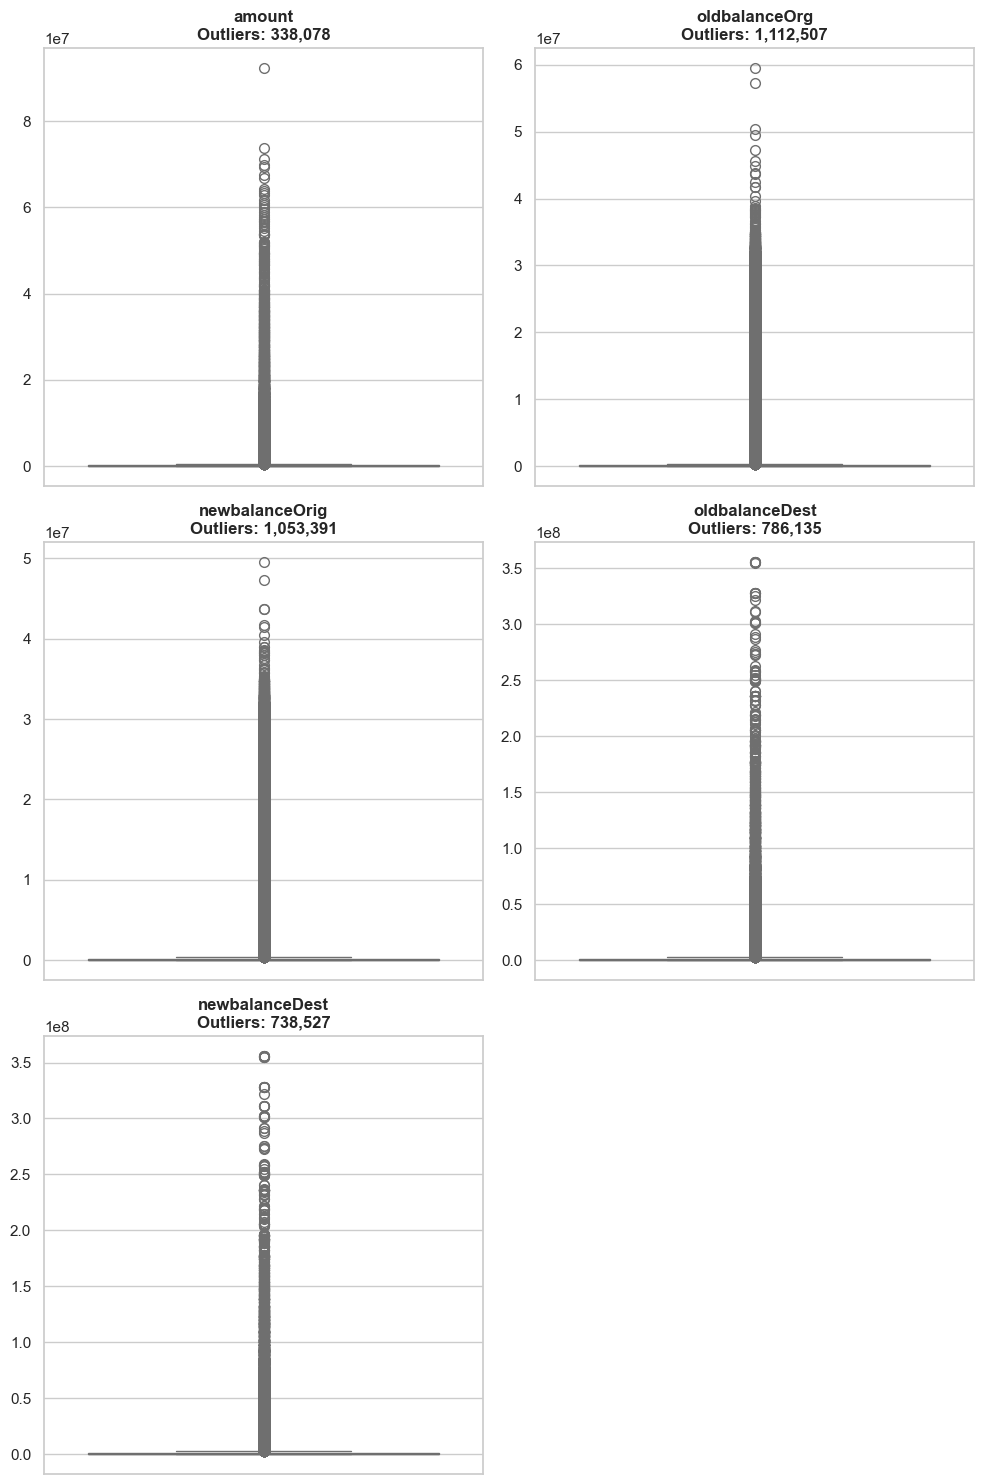

In [19]:
# In this numeric columns we are not mentioning the Step column, beause the Maximum value of step is just 743, but below columns have very high values
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

def plot_outliers_optimized(df, columns):
    sns.set_theme(style='whitegrid')
    n_cols = 2
    n_rows = (len(columns) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        data_array = df[col].to_numpy()
        q1, q3 = np.percentile(data_array, [25, 75]) # use np.percentile, instead of quantile
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        # Vectorized outlier count
        outlier_count = ((data_array < lower_bound) | (data_array > upper_bound)).sum()

        # Efficient Plotting
        sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue', fliersize=7)
        axes[i].set_title(f'{col}\nOutliers: {outlier_count:,}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Call the function to execute the code
plot_outliers_optimized(df, numeric_cols)

### **Observations**
- We have done box plot for the following columns
    - **amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, and newbalanceDest**
- Using Inter Quartile Range (IQR) we have counted number of Outliers in the each column. The count of Outliers per columns as follow
    - **amount**: 3,38,078 outliers out of 63,62,620 rows
    - **oldbalanceOrg**: 11,12,507 outliers out of 63,62,620 rows
    - **newbalanceOrig**: 10,53,391 outliers out of 63,62,620 rows
    - **oldbalanceDest**: 7,86,135 outliers out of 63,62,620 rows
    - **newbalanceDest**: 7,38,527 outliers out of 63,62,620 rows
- from the above we understand that these columns have extreme outliers

- **Note**: We are not mentioning the step column, because 'step' column is related to the time. Per day we have 24 hours, and 24 hours X 31 days. We get the 743. So the maximum number from step column is 743. This column do not have any Outliers.

#### 6.2 Handling Outliers
- By using Log Transformation we can handle the Outliers

In [21]:
def handle_outliers(df, cols):
    # 1. Vectorized Log Transformation
    for col in cols:
        df[f'{col}_log'] = np.log1p(df[col])

    # 2. Outlier Flagging (Using uint8 to save lot of memory of flag values)
    for col in cols:
        q1, q3 = np.percentile(df[col], [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

        # 'uint8' data type is standard for binary flags (0 and 1) representation
        df[f'{col}_outlier'] = ((df[col] < lower) | (df[col] > upper)).astype('uint8')

    # 3. Memory-Efficient Reporting
    print(f"{'Feature':<20} | {'Outlier Count':<15} | {'Memory (MB)':<10}")
    print("-" * 60)
    for col in cols:
        count = df[f'{col}_outlier'].sum()
        mem = df[col].memory_usage(index=False) / 1024**2
        print(f'{col:<20} | {count:15,d} | {mem:.2} MB')

# In previous cell we have defined the numeric cols, by using that simply call the above function
handle_outliers(df, numeric_cols)

Feature              | Outlier Count   | Memory (MB)
------------------------------------------------------------
amount               |         338,078 | 4.9e+01 MB
oldbalanceOrg        |       1,112,507 | 4.9e+01 MB
newbalanceOrig       |       1,053,391 | 4.9e+01 MB
oldbalanceDest       |         786,135 | 4.9e+01 MB
newbalanceDest       |         738,527 | 4.9e+01 MB


In [23]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'hour', 'orig_balance_error', 'dest_balance_error',
       'is_mule_orig', 'is_mule_dest', 'transfer_to_zero_dest',
       'amount_to_orig_ratio', 'is_suspicious_pattern', 'amount_log',
       'oldbalanceOrg_log', 'newbalanceOrig_log', 'oldbalanceDest_log',
       'newbalanceDest_log', 'amount_outlier', 'oldbalanceOrg_outlier',
       'newbalanceOrig_outlier', 'oldbalanceDest_outlier',
       'newbalanceDest_outlier'],
      dtype='object')

### **Observations**
- The **Log Transformation is helps make data less skewed and reduces the impact of outliers so models can learn patterns more effectively.
- After **Log Transformation** we can see some new columns are created. Those are
  - **'amount_log', 'oldbalanceOrg_log', 'newbalanceOrig_log', 'oldbalanceDest_log', 'newbalanceDest_log', 'amount_outlier', 'oldbalanceOrg_outlier', 'newbalanceOrig_outlier', 'oldbalanceDest_outlier', 'newbalanceDest_outlier'**
- At last we have seen the head() of newly created column, which showing the none of the Outliers are existed

#### 6.3 Plotting the Log Transformation
- We are plotting the Histogram to see the **Data Distribution** before and after the **Log Transformation**

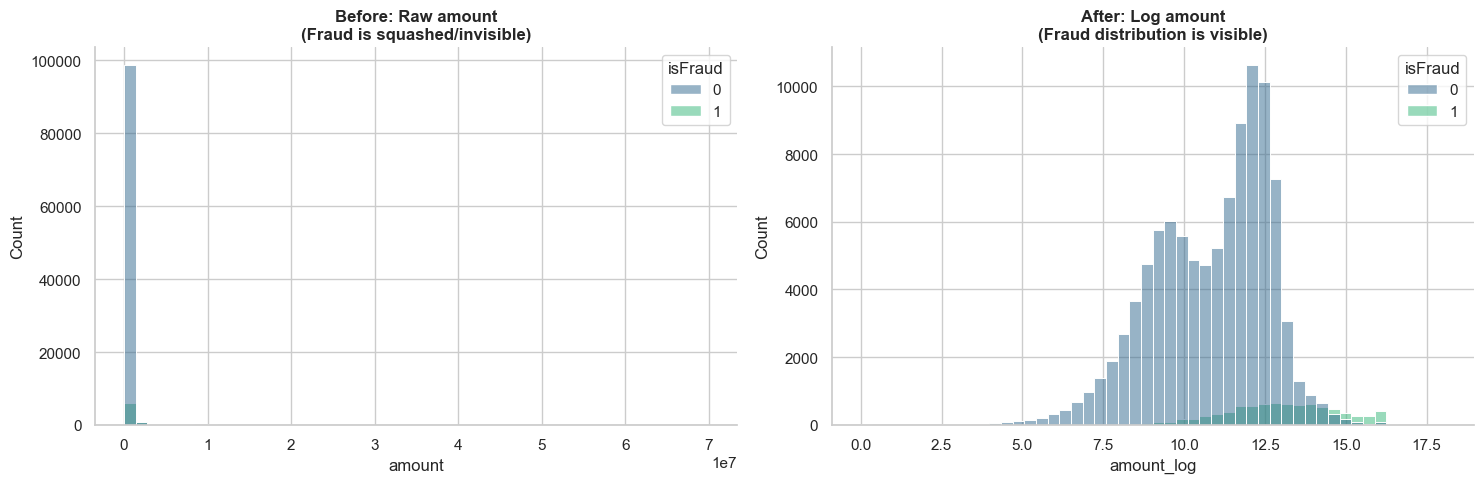

In [25]:
# Defining the function for comparision of distribution

def plot_transformation_impact(df, col):
    # Comparing Raw vs Log Distributions while highlighting the target class
    # Setup the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # 2. Plot the Original columns
    # We are using small sample with all fraud transactions. So we do not missing rare events
    fraud = df[df['isFraud'] == 1]
    non_fraud_sample = df[df['isFraud'] == 0].sample(n=100000, random_state=42)
    plot_df = pd.concat([fraud, non_fraud_sample])

    sns.histplot(data=plot_df, x=col, hue='isFraud', bins=50, ax=ax1, palette='viridis', common_norm=False)
    ax1.set_title(f'Before: Raw {col}\n(Fraud is squashed/invisible)', fontweight='bold')

    # 3. Plot Log-Transformed (The 'After')
    sns.histplot(data=plot_df, x=f'{col}_log', hue='isFraud', bins=50, ax=ax2, palette='viridis', common_norm=False)
    ax2.set_title(f'After: Log {col}\n(Fraud distribution is visible)', fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_transformation_impact(df, 'amount')

### Observations
-  From the Histogram we can understand
    - Original Columns heavily data distributed towords to the **Right-Skewed** (means right side tail). Most of the values/data is there at left side only. This is before the Log Transformation
    - After the **Log Transformation**, we can see data distribution is adjusted towards to the **Middle/Center**.

**Note**: To save computing time, we are not plotting the all the Outlier columns.

#### For plotting the most important column 'amount' use the above code. if we wanted to see the difference of all the original plots with the LogTransformed plots use this below Raw code

### 7. Univariate and Bivariate analysis

#### 7.1 Univariate Analysis (Categorical and Discrete)
- Checking the distribution of type and step

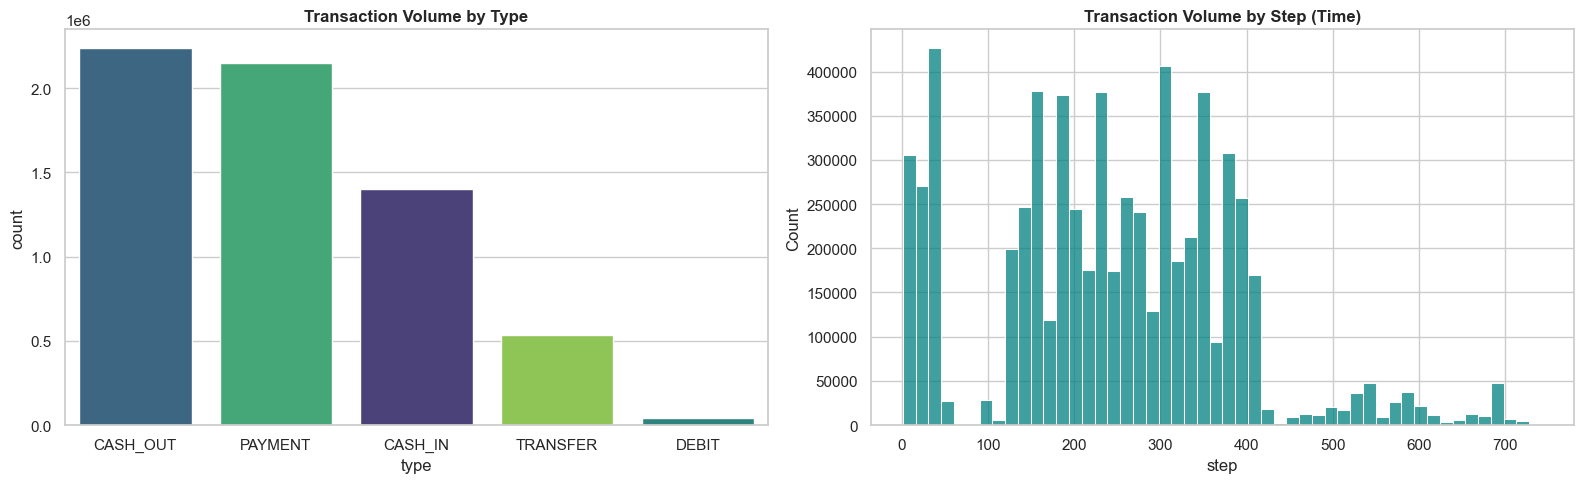

In [27]:
def univariate_analysis(df):
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. Transaction type distribution (Categorical)
    sns.countplot(data=df, x='type', ax=axes[0], palette='viridis', order=df['type']
        .value_counts().index, hue='type', legend=False)
    axes[0].set_title('Transaction Volume by Type', fontweight='bold')

    # 2. Step distribution (Temporal/Discrete)
    # We use a histogram because 'step' has 744 unique values
    sns.histplot(df['step'], bins=50, ax=axes[1], color='teal')
    axes[1].set_title('Transaction Volume by Step (Time)', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Calling the function
univariate_analysis(df)

#### Observations
- From the above Histogram (left chart) we can see CASH_OUT and PAYMENT transaction type have most number of transactions.
- We can see the Histogram (right chart), we can see most of the Transactions are happend from 0 to 400th Step only.

#### 7.2 Bivariate Analysis (Categorical vs Target)
- We have to see which transaction type has more frauds

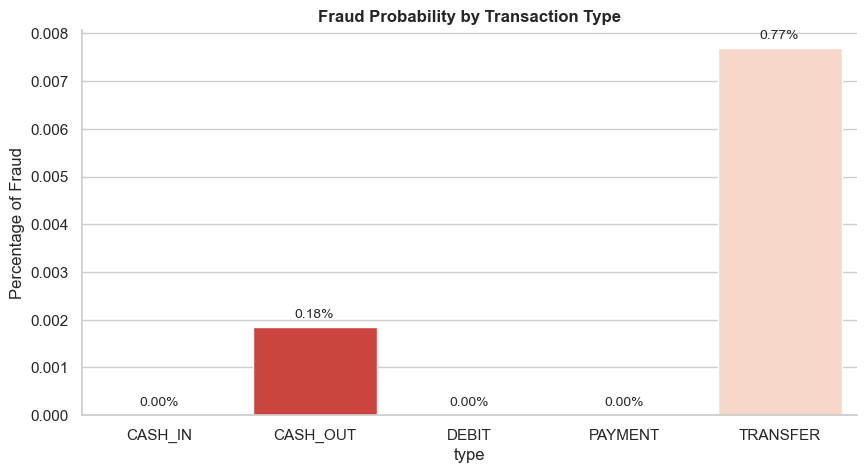

In [31]:
def bivariate_categorical_analysis(df):
    # Calculate the Fraud rate per Category
    fraud_rate = df.groupby('type', observed=False)['isFraud'].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='Reds_r', hue=fraud_rate.index, legend=False)

    # Add percentage labels on top
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
    plt.title('Fraud Probability by Transaction Type', fontweight='bold')
    plt.ylabel('Percentage of Fraud')
    sns.despine()
    plt.show()

bivariate_categorical_analysis(df)

#### Observations
- From the above graph we can see most of the Fraud Transactions are happend in 'TRANSFER' and 'CASH_OUT' type transactions.

#### 7.3 Bivariate Analysis (Numeric vs Target)

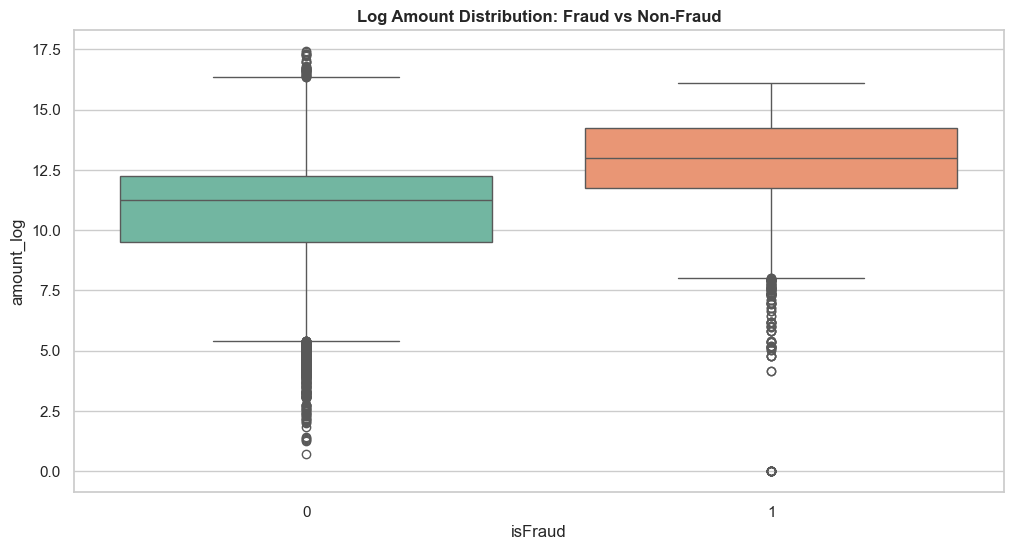

In [33]:
def bivariate_numeric_analysis(df):
    # Use importance sampling: All fraud, and 100k+ non-fraud
    df_sample = pd.concat([df[df['isFraud']==1], df[df['isFraud']==0].sample(100000)])

    plt.figure(figsize=(12, 6))

    # Comparing Amount Log vs Fraud
    sns.boxplot(data=df_sample, x='isFraud', y='amount_log', palette='Set2', hue='isFraud', legend=False)
    plt.title('Log Amount Distribution: Fraud vs Non-Fraud', fontweight='bold')
    plt.show()

bivariate_numeric_analysis(df)

#### Observations
- In the 'amount' column we can see that the Non Fraud transactions have more outliers, comparing to the Fraud transactions. It means both Fraud and NonFraud transactions have the Outliers.

### 8. Advanced EDA (Phik Correlation, Missing Balance, and Temporal plots).

#### 8.1 The **Phik** Correlation heatmap

interval columns not set, guessing: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'hour', 'orig_balance_error', 'is_suspicious_pattern']


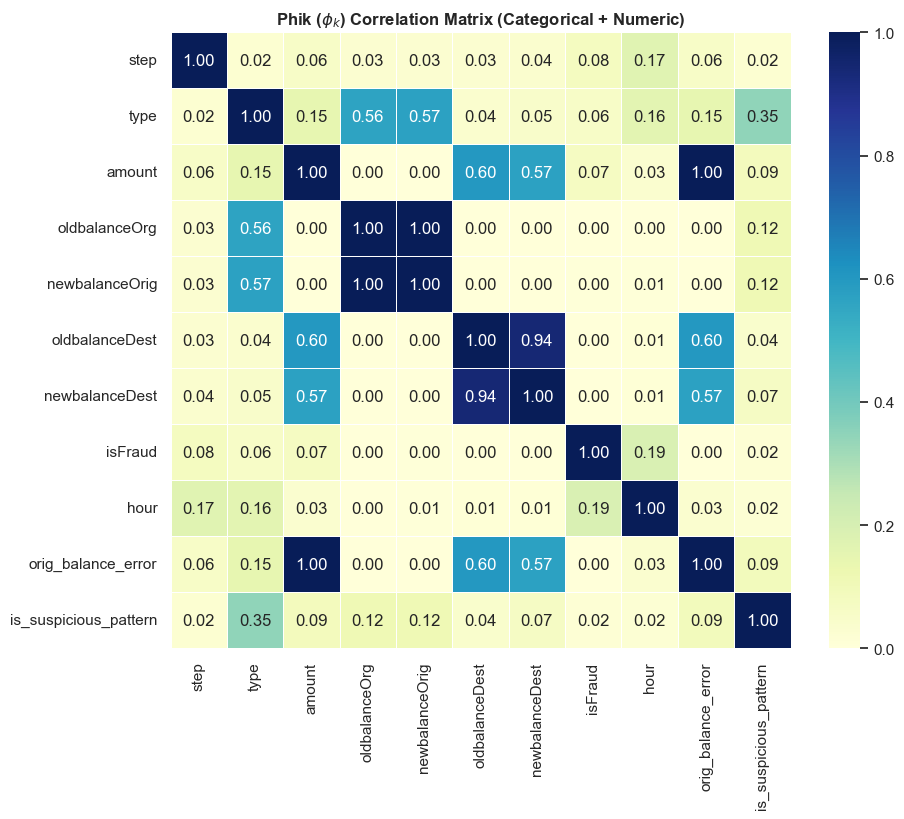

In [35]:
import phik
from phik import resources, report

def plot_phik_correlation(df):
    # Correlation on 6M Rows is slow, so we use large Representative Sample(1000k)
    cols_to_check = [
    'step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'isFraud', 
    'hour', 'orig_balance_error', 'is_suspicious_pattern'
]

    sample_df = df[cols_to_check].sample(n=100000, random_state=42)

    # Calculate Phik matrix
    phik_matrix = sample_df.phik_matrix()

    plt.figure(figsize=(10, 8))
    sns.heatmap(phik_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
    plt.title(r'Phik ($\phi_k$) Correlation Matrix (Categorical + Numeric)', fontweight='bold')
    plt.show()

plot_phik_correlation(df)

#### Observations
- From the above Heatmap, we can see the following columns have the mostly Correlated to each other.
  1. oldbalanceOrg and newBalanceOrg
  2. newbalanceDest and oldBalanceDest
  3. orig_balance_error and amount
  4. oldbalanceDest and amount
  5. orig_balance_error and oldbalanceError

#### 8.2 The Missing Balance Analysis

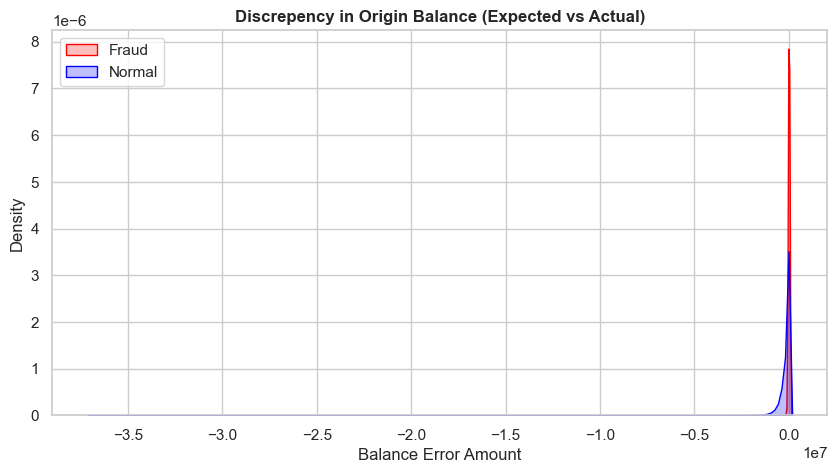

In [37]:
def plot_balance_error_analysis(df):
    # Calculate the temporary error feature. Sometime it becomes the top predictor
    error_orig = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

    plt.figure(figsize=(10, 5))

    # We plot the error distribution for Fraud and Non-Fraud
    sns.kdeplot(error_orig[df['isFraud'] == 1], label='Fraud', fill=True, color='red')
    sns.kdeplot(error_orig[(df['isFraud'] == 0)].sample(100000), label='Normal', fill=True, color='blue')

    plt.title('Discrepency in Origin Balance (Expected vs Actual)', fontweight='bold')
    plt.xlabel('Balance Error Amount')
    plt.legend()
    plt.show()

plot_balance_error_analysis(df)

#### 8.3 The Temporal Fraud Pattern (Hourly)

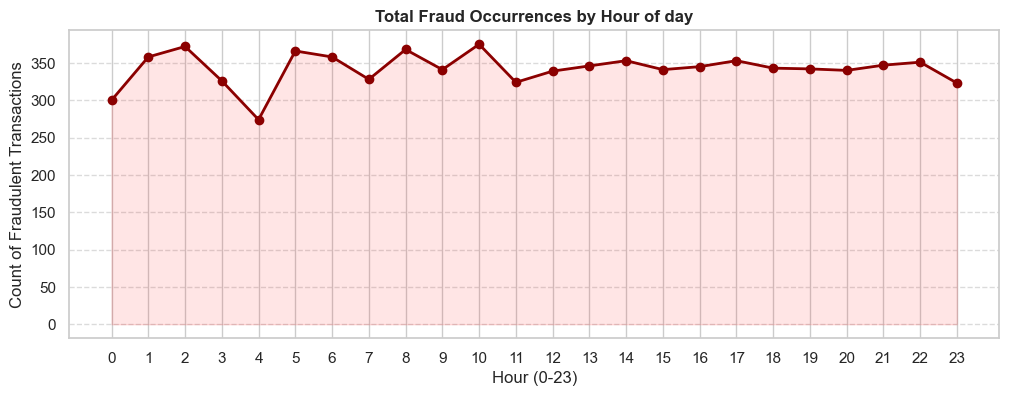

In [39]:
def plot_hourly_fraud_trend(df):
    # convert step to hour of day (0-23) - we have 'hour' column already and using it
    hourly_fraud = df.groupby('hour')['isFraud'].sum()

    plt.figure(figsize=(12, 4))
    plt.plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='darkred', linewidth=2)
    plt.fill_between(hourly_fraud.index, hourly_fraud.values, color='red', alpha=0.1)

    plt.title('Total Fraud Occurrences by Hour of day', fontweight='bold')
    plt.xlabel('Hour (0-23)')
    plt.ylabel('Count of Fraudulent Transactions')
    plt.xticks(range(0, 24))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_hourly_fraud_trend(df)

### 9. One Hot Encoding (where categories become numbers)

In [41]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype='uint8')

### 10. The final Correlation Heatmaps

#### 10.1 The Correlation Heatmap - Between the all numeric columns

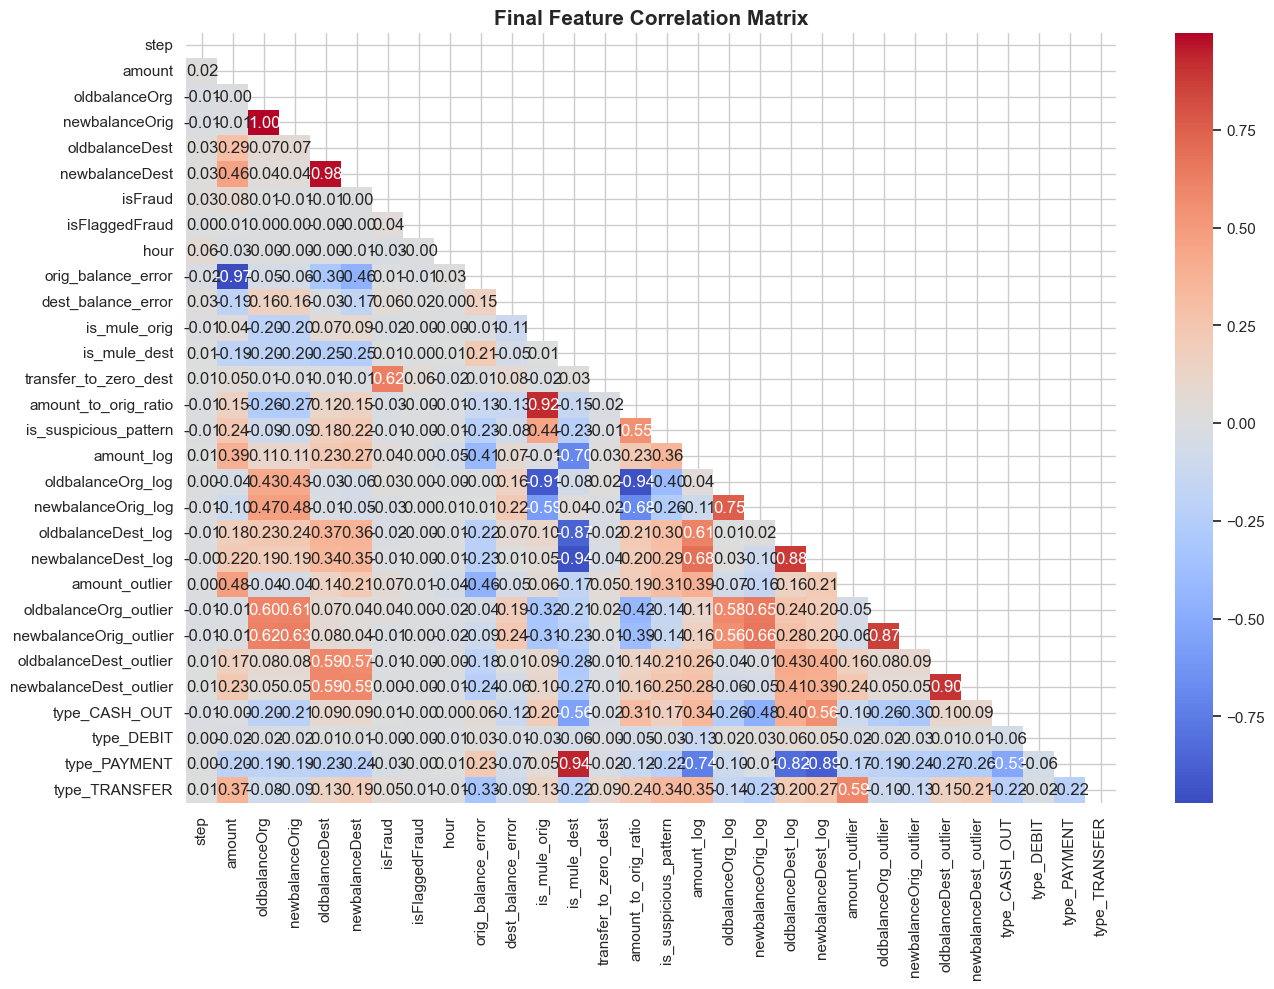

In [43]:
plt.figure(figsize=(15, 10))

# Filtering only numeric types to avoid errors
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=np.triu(corr_matrix))
plt.title('Final Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

#### Observations
- From the above Heatmap, we can see the following columns have the mostly Correlated to each other.
  1. oldbalanceOrg and newBalanceOrg
  2. newbalanceDest and oldBalanceDest
  3. orig_balance_error and amount
  4. oldbalanceDest and amount
  5. orig_balance_error and oldbalanceError

#### 10.2 Correlation Heatmap with the engineered features againest the 'isFraud' column

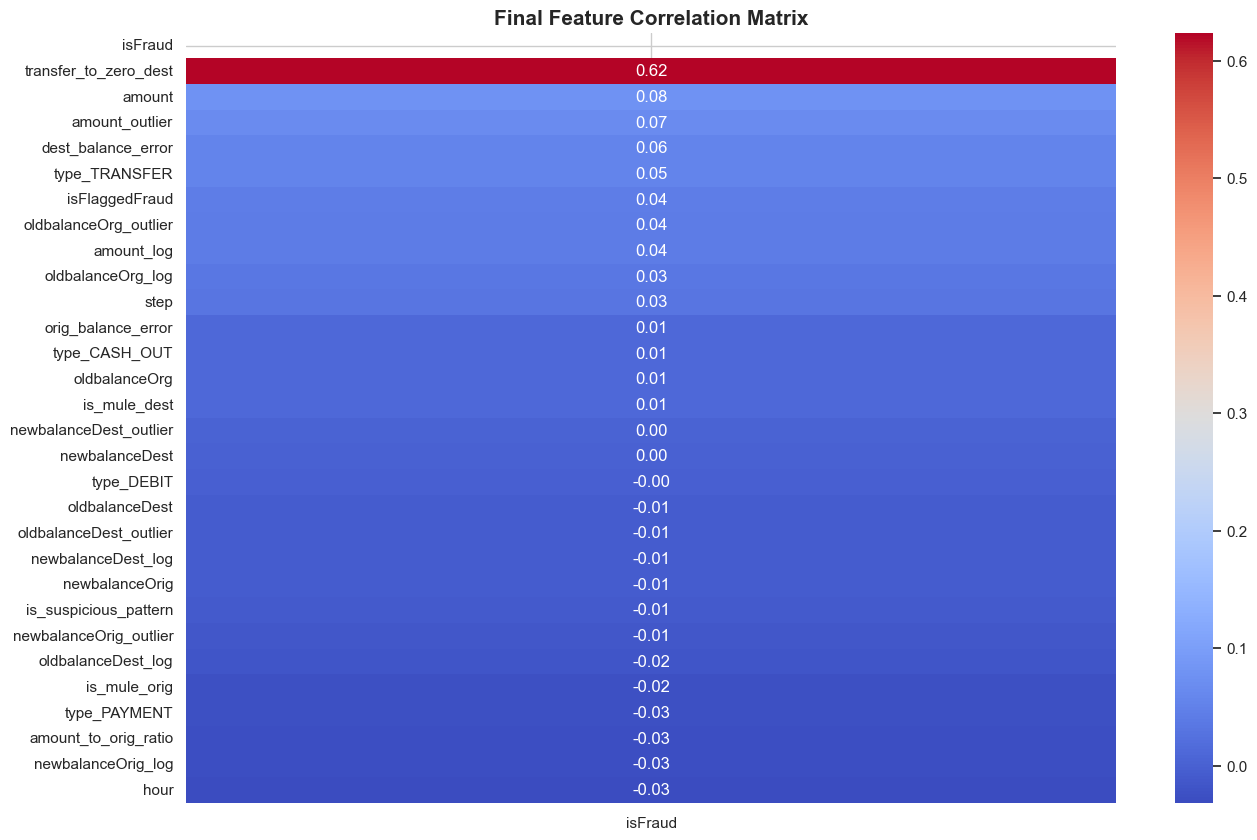

In [44]:
# Correlation Heatmap with the engineered features againest the 'isFraud' column
plt.figure(figsize=(15, 10))

# Filtering only numeric types to avoid errors
corr_matrix = df.select_dtypes(include=[np.number]).corr()[['isFraud']].sort_values(by='isFraud', ascending=False)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=np.triu(corr_matrix))
plt.title('Final Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

#### Observations
- From the above feature correlation heatmap we can see the column 'transfer_to_zero_dest' is highly correlated with the 'isFraud' column.

#### 10.3 Leader of Features which contribute more

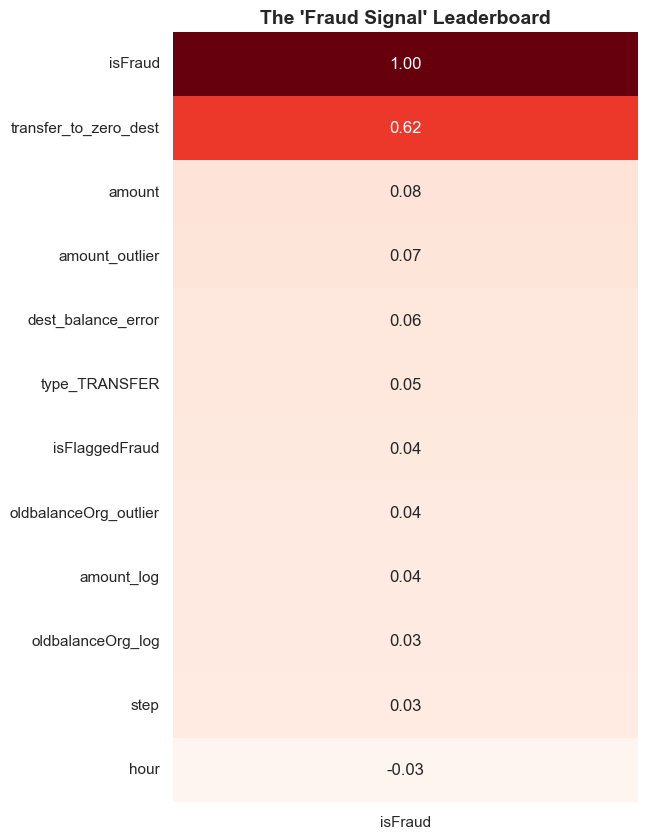

In [46]:
plt.figure(figsize=(6, 10))

# 1. Extract just the 'isFraud' column from your existing matrix
top_features = corr_matrix[['isFraud']].abs().sort_values(by='isFraud', ascending=False).head(12)

# 2. Plot the leaderboard
# We use loc to pull the actual (non-absolute) values from the matrix for the plot
sns.heatmap(corr_matrix.loc[top_features.index, ['isFraud']], 
            annot=True, cmap='Reds', fmt=".2f", cbar=False)

plt.title("The 'Fraud Signal' Leaderboard", fontweight='bold', fontsize=14)
plt.show()

#### Observations
- From the above feature correlation heatmap we can see the column 'transfer_to_zero_dest' is highly correlated with the 'isFraud' column.

## 11. Machine Learning
### 11.1 Supervised Machine Learning Models
#### 11.1.1 Logistic Regression
- Before starting the ML steps, make sure you must have only Numerical data. If any non nnumerical data is there, make sure to delete that, otherwise none of the ML algorithms will work.
- Before starting the ML steps, we need to Separate the Feature columns and Target columns.

In [49]:
from sklearn.metrics import (precision_recall_curve, auc, average_precision_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score, ConfusionMatrixDisplay)

def final_evaluation_suite(pipeline, X_test, y_test):
    # 1. Get predictions and probabilities
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1]

    # 2. Basic Metrics Summary
    print("-"*60)
    print(f"{'Overall PERFORMANCE METRIC': ^60}")
    print("-"*60)
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"Average Precision: {average_precision_score(y_test, y_proba):.4f}")
    print("-"*60)

    # 3. Detailed Classification Report
    print("\n" + "="*60)
    print(f"{'DETAILED CLASSIFICATION REPORT':^60}")
    print("-"*60)
    print(classification_report(y_test, y_pred))

    # 4. Visual Evaluations (Confusion Matrix & PR curve)
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Left Plot: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Confusion Matrix', fontweight='bold')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # Right Plot: Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax[1].plot(recall, precision, color='darkorange', lw=3, label=f'AP = {average_precision_score(y_test, y_proba):.4f}')
    ax[1].fill_between(recall, precision, alpha=0.2, color='orange')
    ax[1].set_title('Precision-Recall Curve', fontweight='bold')
    ax[1].set_xlabel('Recall (Fraud Caught)')
    ax[1].set_ylabel('Precision (Flag Accuracy)')
    ax[1].legend(loc='lower left')

    plt.tight_layout()
    plt.show()

    # 5. Finalcial impact analysis
    total_fraud_amt = X_test.loc[y_test == 1, 'amount'].sum()
    caught_fraud_amt = X_test.loc[(y_test == 1) & (y_pred == 1), 'amount'].sum()
    savings_ratio = (caught_fraud_amt / total_fraud_amt) * 100 if total_fraud_amt > 0 else 0

    print("\n" + "-"*60)
    print(f"{'FINANCIAL IMPACT ANALYSIS':^60}")
    print("-"*60)
    print(f"Total Fraud Value in Test Set: ${total_fraud_amt:,.2f}")
    print(f"Total Fraud value PROTECTED: ${caught_fraud_amt:,.2f}")
    print(f"Model Savings Efficiency: {savings_ratio:.2f}%")

#### Purpose of the above Function
- From online I heard that in Financial institutions like banks will always choose there models in the Form of how much money was saved from not being fraud, is considered as a High Priority. Based on this the above function will helpful and represent how much amount was saved not being the Fraud.
- This can give when you call the Function with the test data only, and the amount is in the Dollers Scale.

In [51]:
def find_optimal_threshold(pipeline, X_test, y_test, start=0.5, end=0.96, step=0.05, max_fn=3):
    """
    Sweeps through thresholds to find the balance between False Positives 
    and False Negatives.
    """
    # 1. Get probabilities from the Hybrid CatBoost Pipeline
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    thresholds = np.arange(start, end, step)

    print(f"{'Threshold':<12} | {'FP (False Alarms)':<18} | {'FN (Missed Fraud)':<18} | Status")
    print("-" * 70)

    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        
        # Determine status based on the business constraint (max_fn)
        status = "STABLE" if fn <= max_fn else "LOSING FRAUD!"
        print(f"{t:<12.2f} | {fp:<18} | {fn:<18} | {status}")
        
    return y_probs

def evaluate_custom_threshold(y_probs, y_test, threshold):
    """
    Applies a specific threshold and outputs the final performance metrics.
    """
    y_final_pred = (y_probs >= threshold).astype(int)
    
    print(f"\nOptimized (Threshold {threshold}):")
    print("-" * 45)
    print(confusion_matrix(y_test, y_final_pred))
    
    return y_final_pred

# --- Execution ---
# 1. Run the Sweep
#y_probabilities = find_optimal_threshold(pipeline_cbc, X_test, y_test)

# 2. Apply the chosen Threshold
# final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.64)

#### Purpose of the above function
- This above function is useful to Tune the model Performance based on the Threshold value.

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9824
ROC AUC Score: 0.9989
Average Precision: 0.8087
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      1.00      0.13      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.99      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524



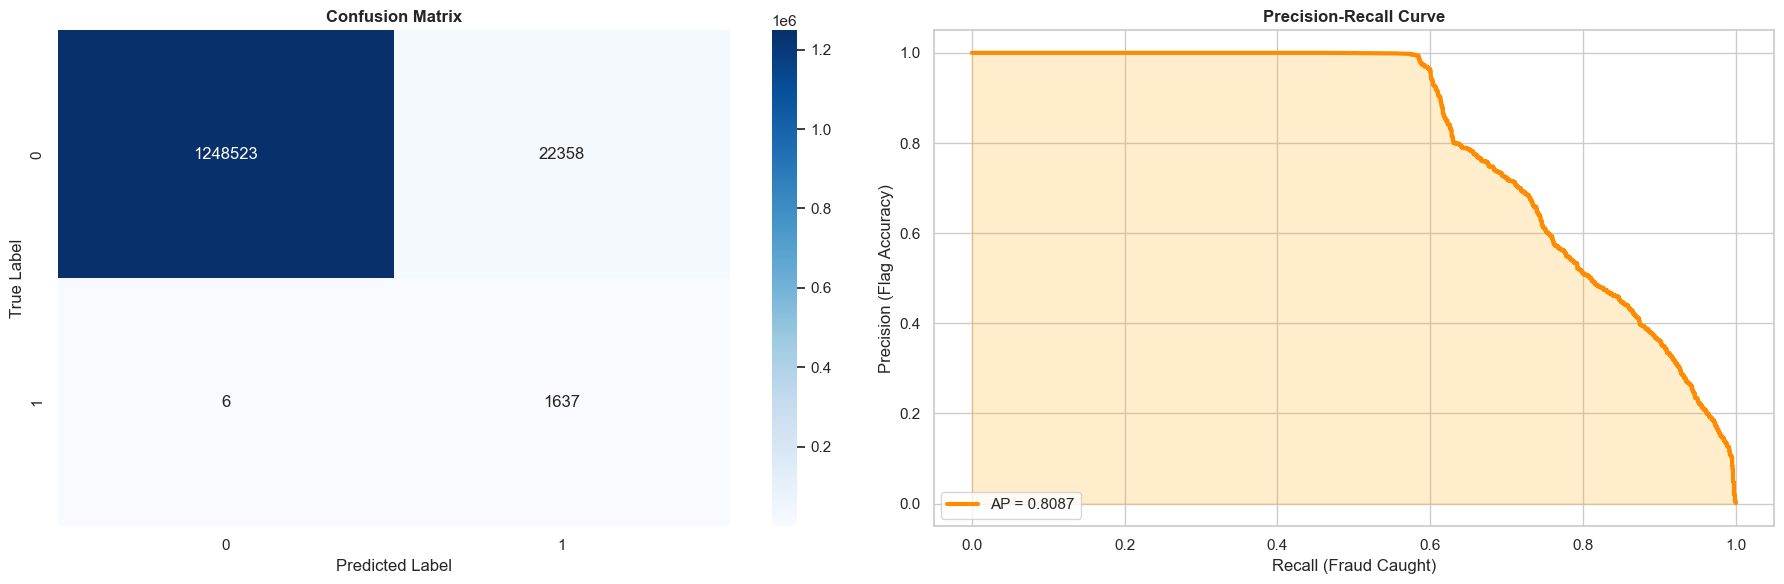


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,381,994,649.26
Model Savings Efficiency: 99.97%


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression

# 1. Split the data into target and features
cols_to_drop = ['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']
X = df.drop(cols_to_drop, axis=1)
y = df['isFraud']

# Now split the Features into train and test. Stratify ensures both sets have same % of frauds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Preprocessing step
# Num Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) # For better outlier handling purpose
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, make_column_selector(dtype_include=['number']))
])

# 3. Model with the Class weights
pipeline_lg = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1))
])

# 4. Fit and evaluate the model
pipeline_lg.fit(X_train, y_train)
final_evaluation_suite(pipeline_lg, X_test, y_test)

In [57]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_lg, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.50)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 22358              | 6                  | LOSING FRAUD!
0.55         | 19945              | 7                  | LOSING FRAUD!
0.60         | 17503              | 8                  | LOSING FRAUD!
0.65         | 15183              | 8                  | LOSING FRAUD!
0.70         | 12798              | 13                 | LOSING FRAUD!
0.75         | 10403              | 22                 | LOSING FRAUD!
0.80         | 7942               | 41                 | LOSING FRAUD!
0.85         | 5543               | 77                 | LOSING FRAUD!
0.90         | 3461               | 123                | LOSING FRAUD!
0.95         | 1903               | 223                | LOSING FRAUD!

Optimized (Threshold 0.5):
---------------------------------------------
[[1248523   22358]
 [      6    1637]]


#### Observations
- From the above output we can see that Logistic Regression has captured almost legitimate transactions are detected as fraud. This can make Customers will get frastration on the banking services. So in Financial Institutions like banks, this is not a great model.
- The Confusion matrix have True Negitives (1248523)[Actual non Frauds], False Positives (22358)[Legitimate transaction are flagged as Fraud] (This is also called as Type 1 Error), False Negitives (6) [True fraud cases are not detected] (This is also called as the False Negitives), and True Positives (1637)[total detected fraud transactions].

### 11.1.2 Decision Tree Model

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9998
ROC AUC Score: 0.9994
Average Precision: 0.9975
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.94      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



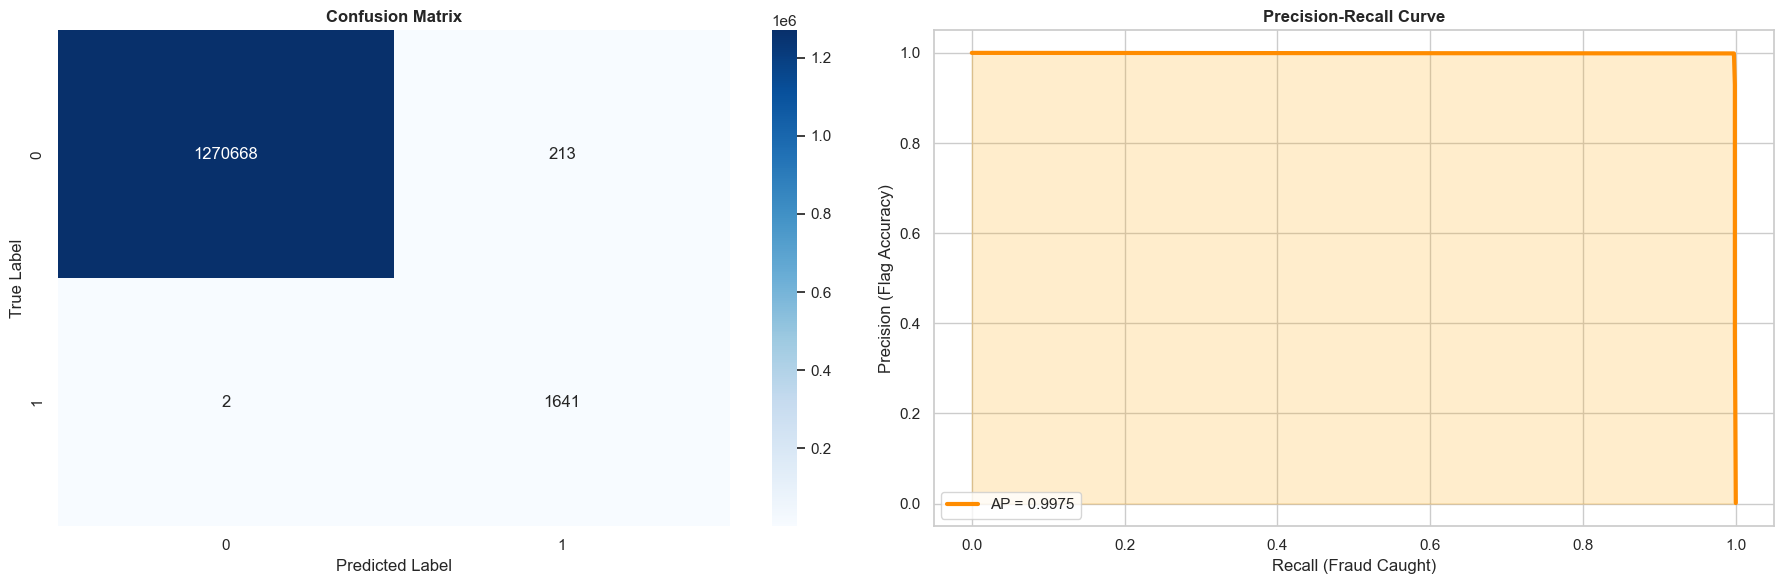


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,382,528,838.68
Model Savings Efficiency: 99.99%


In [59]:
from sklearn.tree import DecisionTreeClassifier

# We already have preprocessor on Above, So we are directly calling it and defining model inside the Pipeline
pipeline_dt = Pipeline([
    ('prep', preprocessor),
    ('dt', DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'))
])

# Fit the Model and make predictions
pipeline_dt.fit(X_train, y_train)
final_evaluation_suite(pipeline_dt, X_test, y_test)

In [61]:
# --- Updated Execution Flow ---
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_dt, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.90)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 213                | 2                  | STABLE
0.55         | 213                | 2                  | STABLE
0.60         | 213                | 2                  | STABLE
0.65         | 213                | 2                  | STABLE
0.70         | 124                | 2                  | STABLE
0.75         | 124                | 2                  | STABLE
0.80         | 124                | 2                  | STABLE
0.85         | 124                | 2                  | STABLE
0.90         | 124                | 2                  | STABLE
0.95         | 3                  | 4                  | LOSING FRAUD!

Optimized (Threshold 0.9):
---------------------------------------------
[[1270757     124]
 [      2    1641]]


#### Observations
- The Confusion matrix have True Negitives (1270757)[Actual non Frauds], False Positives (124)[Legitimate transaction are flagged as Fraud] (This is also called as Type 1 Error), False Negitives (2) [True fraud cases are not detected] (This is also called as the False Negitives), and True Positives (1641)[total detected fraud transactions].
- The decision tree performed well with this Fraud detection project. It have detected almost all the Fraud transactions, but left with the only two fraud cases.
- Maybe these two fraud cases are followed Normal non fraud transactions. That is why Decision tree is unable to find these Fraud cases.
- If we observe, almost we have 124 False Positive Transactions are there. If the False positives are reduced, then Decision tree is the best model, to detect the Fraud cases.

### 11.1.3 GaussianNB(Naive Bayes Model)

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9055
ROC AUC Score: 0.9902
Average Precision: 0.4089
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1270881
           1       0.01      0.99      0.03      1643

    accuracy                           0.91   1272524
   macro avg       0.51      0.95      0.49   1272524
weighted avg       1.00      0.91      0.95   1272524



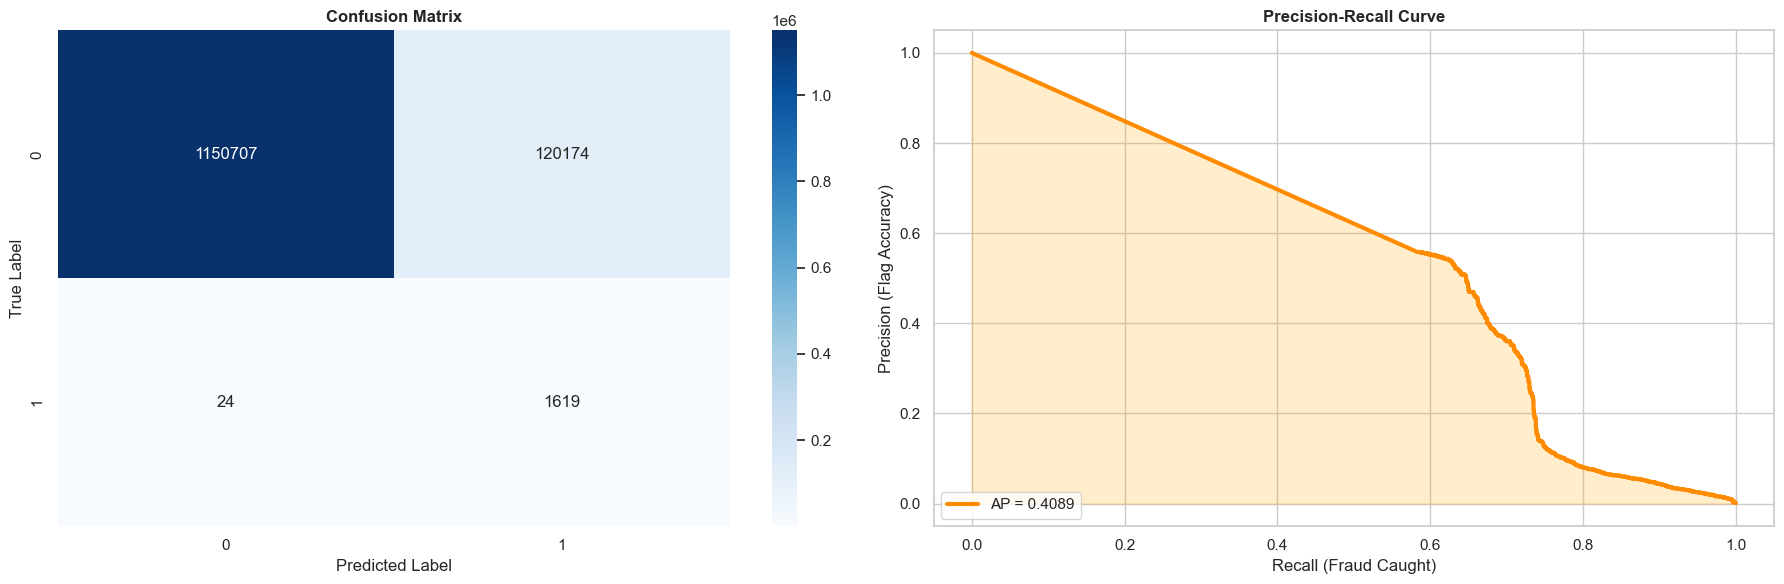


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,381,426,630.87
Model Savings Efficiency: 99.95%


In [63]:
from sklearn.naive_bayes import GaussianNB

# Load the model inside the Pipeline
pipeline_gnb = Pipeline([
    ('prep', preprocessor),
    ('gnb', GaussianNB())
])

# Fit the Pipeline
pipeline_gnb.fit(X_train, y_train)
final_evaluation_suite(pipeline_gnb, X_test, y_test)

In [65]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_gnb, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.50)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 120174             | 24                 | LOSING FRAUD!
0.55         | 117114             | 26                 | LOSING FRAUD!
0.60         | 113760             | 27                 | LOSING FRAUD!
0.65         | 110172             | 28                 | LOSING FRAUD!
0.70         | 106307             | 30                 | LOSING FRAUD!
0.75         | 101780             | 33                 | LOSING FRAUD!
0.80         | 96250              | 42                 | LOSING FRAUD!
0.85         | 89160              | 45                 | LOSING FRAUD!
0.90         | 78784              | 53                 | LOSING FRAUD!
0.95         | 61089              | 79                 | LOSING FRAUD!

Optimized (Threshold 0.5):
---------------------------------------------
[[1150707  120174]
 [     24    1619]]


#### Observations
- From the above output, we can see that False Positive cases are increased extremely. We can not consider Model as a Good model.

### 11.1.4 LightGBM Model

[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: in_unbalance
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: in_unbalance
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: in_unbalance
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: in_unbalance
------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9700
ROC AUC Score: 0.9625
Average Precision: 0.0390
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.04      0.97      0.08      1643

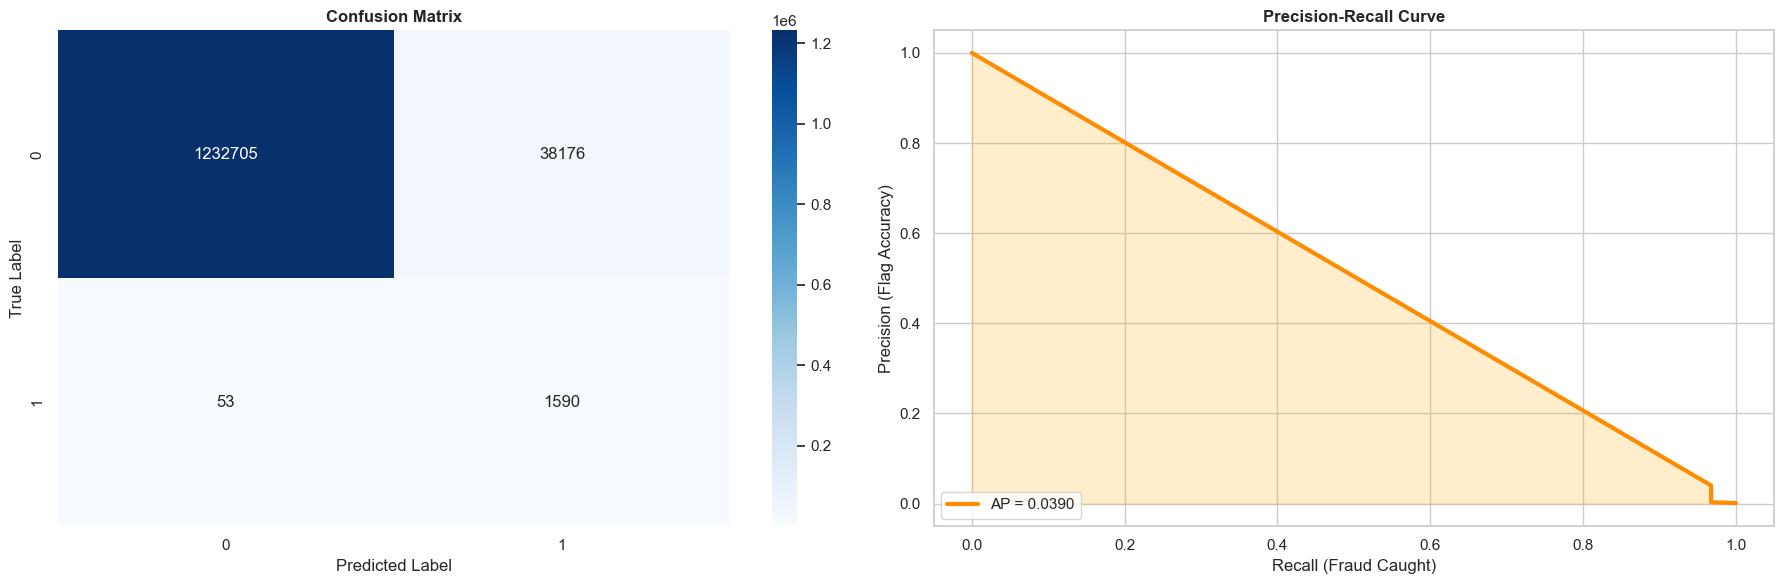


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,372,564,808.29
Model Savings Efficiency: 99.58%


In [67]:
import lightgbm as lgb

# 1. Calculate the 'Scale' once
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
scale_weight = num_negative / num_positive

# Defining the model and preprocessor in Pipeline
pipeline_lgbm = Pipeline([
    ('prep', preprocessor),
    ('lgbm', lgb.LGBMClassifier(
        object = 'binary',
        in_unbalance = False,
        scale_pos_weight = scale_weight,
        metric = 'binary_logloss',
        n_estimators = 100,
        random_state = 42,
        n_jobs = -1,
        verbose=0
    ))
])

pipeline_lgbm.fit(X_train, y_train)
final_evaluation_suite(pipeline_lgbm, X_test, y_test)

In [69]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_lgbm, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.50)

[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: in_unbalance
Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 38176              | 53                 | LOSING FRAUD!
0.55         | 38176              | 53                 | LOSING FRAUD!
0.60         | 38165              | 53                 | LOSING FRAUD!
0.65         | 38163              | 53                 | LOSING FRAUD!
0.70         | 38163              | 53                 | LOSING FRAUD!
0.75         | 38162              | 53                 | LOSING FRAUD!
0.80         | 38162              | 53                 | LOSING FRAUD!
0.85         | 38162              | 53                 | LOSING FRAUD!
0.90         | 38157              | 53                 | LOSING FRAUD!
0.95         | 38129              | 53                 | LOSING FRAUD!

Optimized (Threshold 0.5):
---------------------------

#### Observations
- From the above LightGBM model output we can see that, False Negitive transactions are increased. It means the LightGBM model is not efficient to detect the actual fraud cases.
- It have less False Positives cases comparing with the Naive Bayes models, but more False negitives than the Naive Bayes model.

### 11.1.5 CatBoost Model (Category Boost Model)

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9999
ROC AUC Score: 0.9999
Average Precision: 0.9987
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.92      1.00      0.96      1643

    accuracy                           1.00   1272524
   macro avg       0.96      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



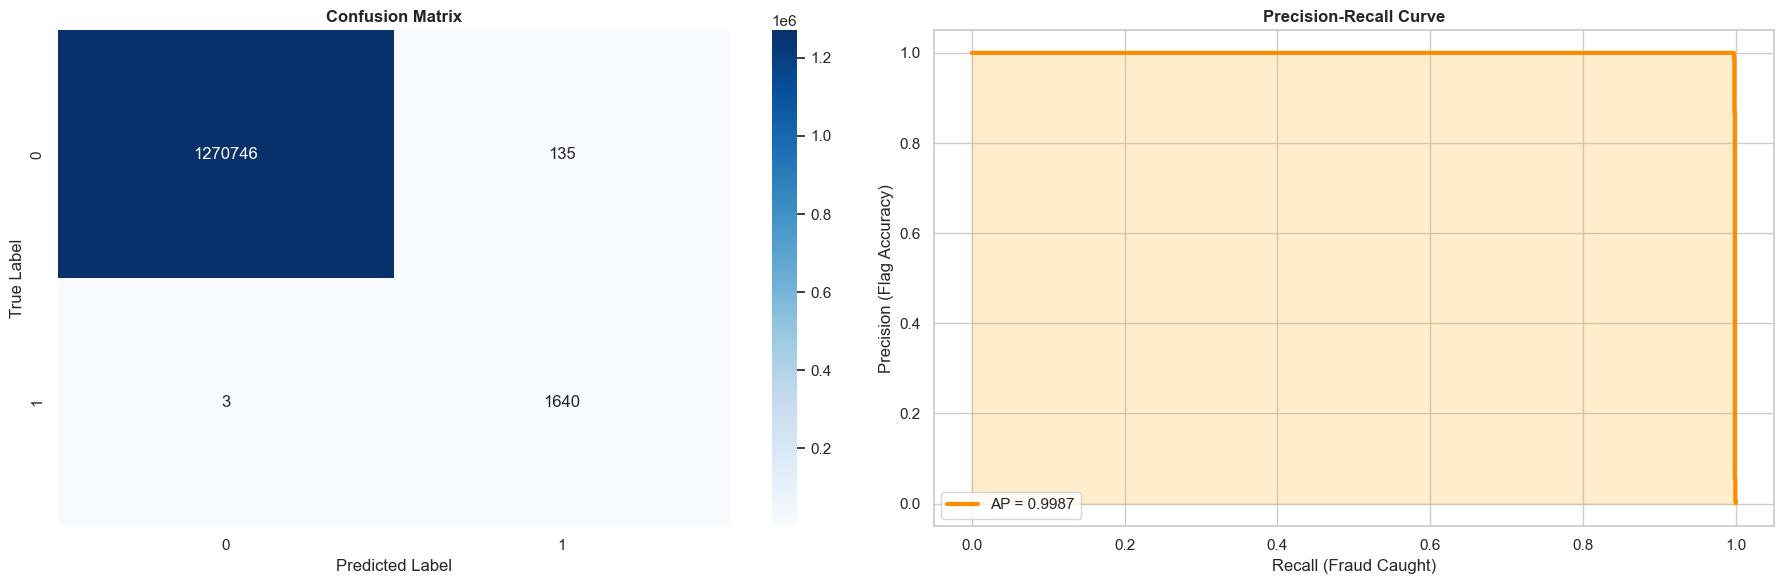


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,382,347,110.57
Model Savings Efficiency: 99.99%


In [71]:
from catboost import CatBoostClassifier

# We are using the Same scale_weight above created

# Define Pipeline with the Preprocessor and Model
pipeline_cbc = Pipeline([
    ('prep', preprocessor),
    ('cbc', CatBoostClassifier(
        iterations = 100,
        learning_rate = 0.1,
        loss_function = 'Logloss',
        eval_metric = 'F1',
        scale_pos_weight = scale_weight,
        random_state = 42,
        verbose = 0
    ))
])

pipeline_cbc.fit(X_train, y_train)
final_evaluation_suite(pipeline_cbc, X_test, y_test)

In [73]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_cbc, X_test, y_test)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 135                | 3                  | STABLE
0.55         | 119                | 3                  | STABLE
0.60         | 96                 | 3                  | STABLE
0.65         | 75                 | 3                  | STABLE
0.70         | 60                 | 3                  | STABLE
0.75         | 46                 | 3                  | STABLE
0.80         | 31                 | 3                  | STABLE
0.85         | 21                 | 3                  | STABLE
0.90         | 14                 | 4                  | LOSING FRAUD!
0.95         | 4                  | 4                  | LOSING FRAUD!


In [75]:
# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.85)


Optimized (Threshold 0.85):
---------------------------------------------
[[1270860      21]
 [      3    1640]]


#### Observations
- The CatBoost model worked well in terms of Reducing the False Positives (just 21 only), but it have more False Negitives (3 only), which is higher  than the Decision Tree Model Output, But in the Realworld scenario's CatBoost Model is more stable than the Decision Tree Model. So we can choose the CatBoost Model for the Hybrid Stack ML Model.

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 1.0000
ROC AUC Score: 0.9998
Average Precision: 0.9987
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



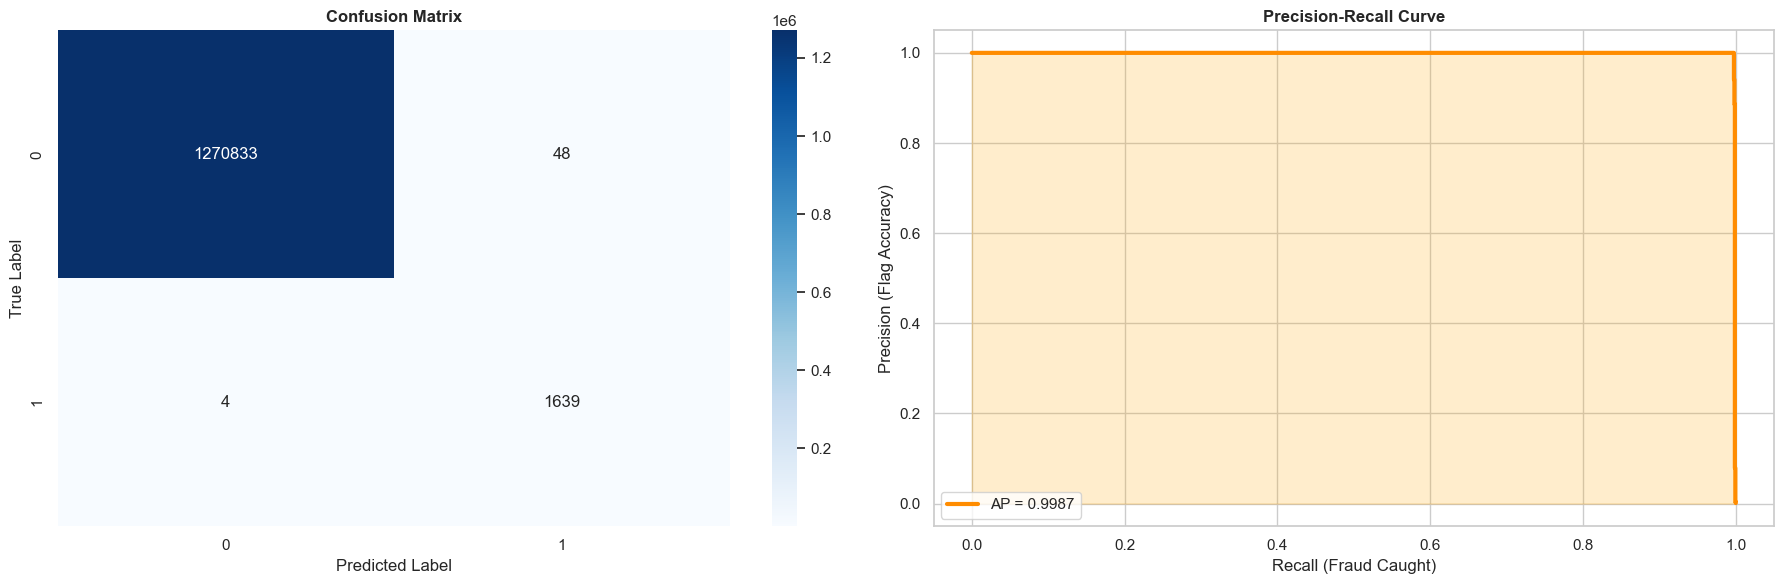


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,382,069,139.69
Model Savings Efficiency: 99.97%


In [65]:
# Now we are Increasing the iteration from 100 to 200
pipeline_cbc = Pipeline([
    ('prep', preprocessor),
    ('cbc', CatBoostClassifier(
        iterations = 200,
        learning_rate = 0.1,
        loss_function = 'Logloss',
        eval_metric = 'F1',
        scale_pos_weight = scale_weight,
        random_state = 42,
        verbose = 0
    ))
])

pipeline_cbc.fit(X_train, y_train)
final_evaluation_suite(pipeline_cbc, X_test, y_test)

#### Observations
- In the above we have increased iteration of the CatBoost model from the 100 to 200. When we increase the CatBoost model iterations, it is reduced the False Positives from 135 to just 40+ only, but significantly we have got the increased False negitives. In realworld if we have more False Negitives, it means Financial loss is more.

### 11.1.6 eXtreme Gradient Boosting Model (XGBoost Model)

C:\Users\myoge\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:38:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9998
ROC AUC Score: 0.9997
Average Precision: 0.9942
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      0.99      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.95      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



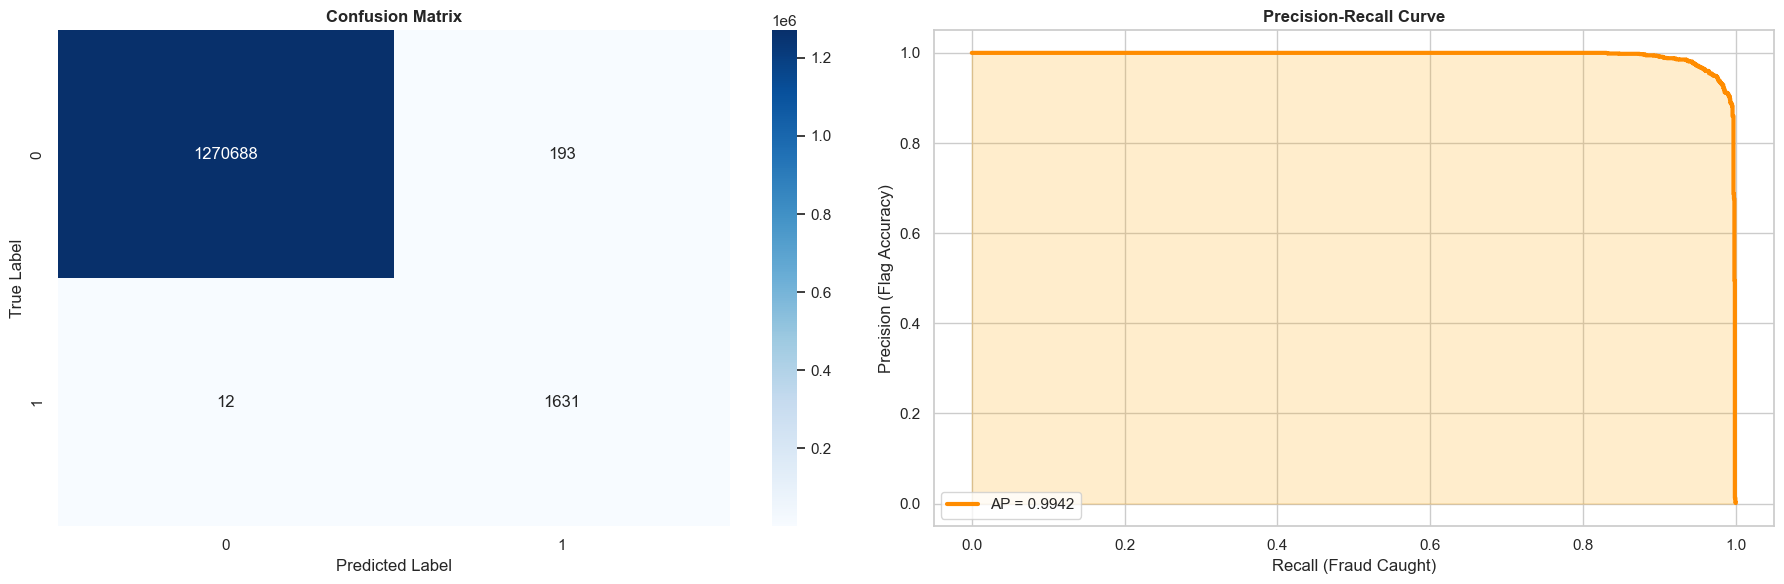


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,381,833,165.54
Model Savings Efficiency: 99.96%


In [77]:
import xgboost as xgb
from xgboost import XGBClassifier

# We are using the Scale weight which is defined above

# Loading preprocessor and model inside the Pipeline
pipeline_xgb = Pipeline([
    ('prep', preprocessor),
    ('xgb', xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=scale_weight,
        random_state=42
    ))
])

# Fit the Pipeline
pipeline_xgb.fit(X_train, y_train)
final_evaluation_suite(pipeline_xgb, X_test, y_test)

In [81]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_xgb, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.50)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 193                | 12                 | LOSING FRAUD!
0.55         | 186                | 12                 | LOSING FRAUD!
0.60         | 180                | 13                 | LOSING FRAUD!
0.65         | 174                | 14                 | LOSING FRAUD!
0.70         | 171                | 14                 | LOSING FRAUD!
0.75         | 164                | 16                 | LOSING FRAUD!
0.80         | 160                | 18                 | LOSING FRAUD!
0.85         | 153                | 24                 | LOSING FRAUD!
0.90         | 145                | 24                 | LOSING FRAUD!
0.95         | 125                | 27                 | LOSING FRAUD!

Optimized (Threshold 0.5):
---------------------------------------------
[[1270688     193]
 [     12    1631]]


#### Observations
- XGBoost Model have given 12 False negitives. it means Financial loss is more.

### 11.1.7 We can try the BalancedRandomForestClassifier

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9998
ROC AUC Score: 0.9996
Average Precision: 0.9987
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.88      1.00      0.93      1643

    accuracy                           1.00   1272524
   macro avg       0.94      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



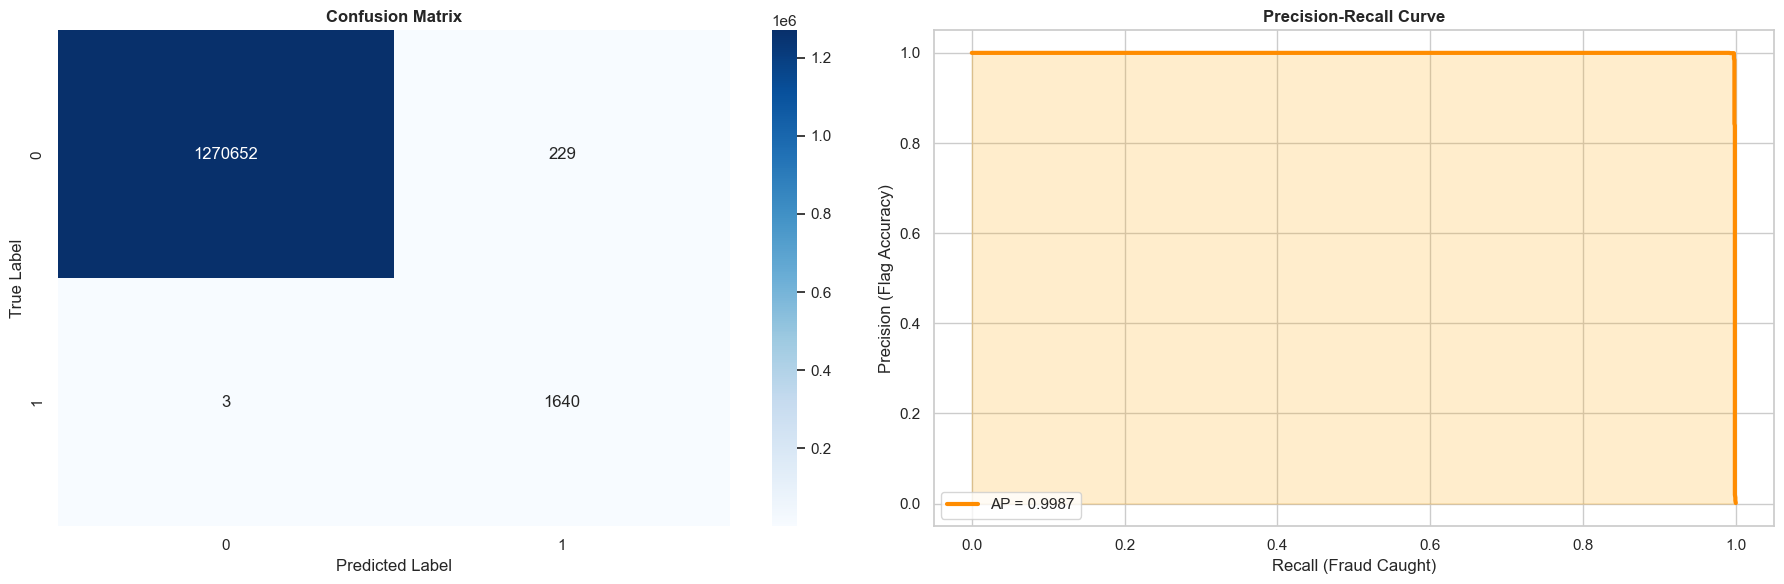


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $2,382,347,110.57
Model Savings Efficiency: 99.99%


In [83]:
from imblearn.ensemble import BalancedRandomForestClassifier

# 1. Define the Balanced Random Forest (The FN Killer)
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,
    sampling_strategy='all',
    replacement=True,
    max_depth=15,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

# fit the Pipeline
pipeline_brf = Pipeline([
    ('prep', preprocessor),
    ('brf', brf_model)
])

pipeline_brf.fit(X_train, y_train)
final_evaluation_suite(pipeline_brf, X_test, y_test)

In [85]:
# Fine tuning the above model

# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_brf, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.72)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 238                | 3                  | STABLE
0.55         | 172                | 3                  | STABLE
0.60         | 117                | 3                  | STABLE
0.65         | 75                 | 3                  | STABLE
0.70         | 31                 | 3                  | STABLE
0.75         | 12                 | 4                  | LOSING FRAUD!
0.80         | 4                  | 4                  | LOSING FRAUD!
0.85         | 1                  | 4                  | LOSING FRAUD!
0.90         | 1                  | 4                  | LOSING FRAUD!
0.95         | 1                  | 10                 | LOSING FRAUD!

Optimized (Threshold 0.72):
---------------------------------------------
[[1270856      25]
 [      3    1640]]


#### Observations
- Balanced Random Forest is some how better than the LightGBM and XGBoost model. This model have left only 3 False negitives and 25 False Positives. It is also working great, like CatBoost Model.

## 11.2 Unsupervised Machine Learning Models
### 11.2.1 Isolation Forest - We are applying this model on the Test data only.

In [87]:
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import IsolationForest

class IsoForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, contamination=0.01, random_state=42):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.random_state = random_state

    def fit(self, X, y=None):
        X, y = check_X_y(X, y) if y is not None else (check_array(X), None)
        
        self.model_ = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state
        )
        self.model_.fit(X)
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        raw_preds = self.model_.predict(X)
        # Map: 1 = Normal and it becomes (0 means non frauds) and Anomaly(-1) becomes as 1.
        return np.where(raw_preds == -1, 1, 0)

    def predict_proba(self, X):
        check_is_fitted(self)
        X = check_array(X)
        # Use decision_function (lower is more anomalous)
        scores = self.model_.decision_function(X)
        # Convert to [0, 1] probability range; lower score = higher fraud prob
        # Professional standard: use a soft mapping or robust scaling
        prob_fraud = (scores.max() - scores) / (scores.max() - scores.min() + 1e-9)
        return np.vstack([1 - prob_fraud, prob_fraud]).T

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9978
ROC AUC Score: 0.8233
Average Precision: 0.0195
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.03      0.02      0.02      1643

    accuracy                           1.00   1272524
   macro avg       0.51      0.51      0.51   1272524
weighted avg       1.00      1.00      1.00   1272524



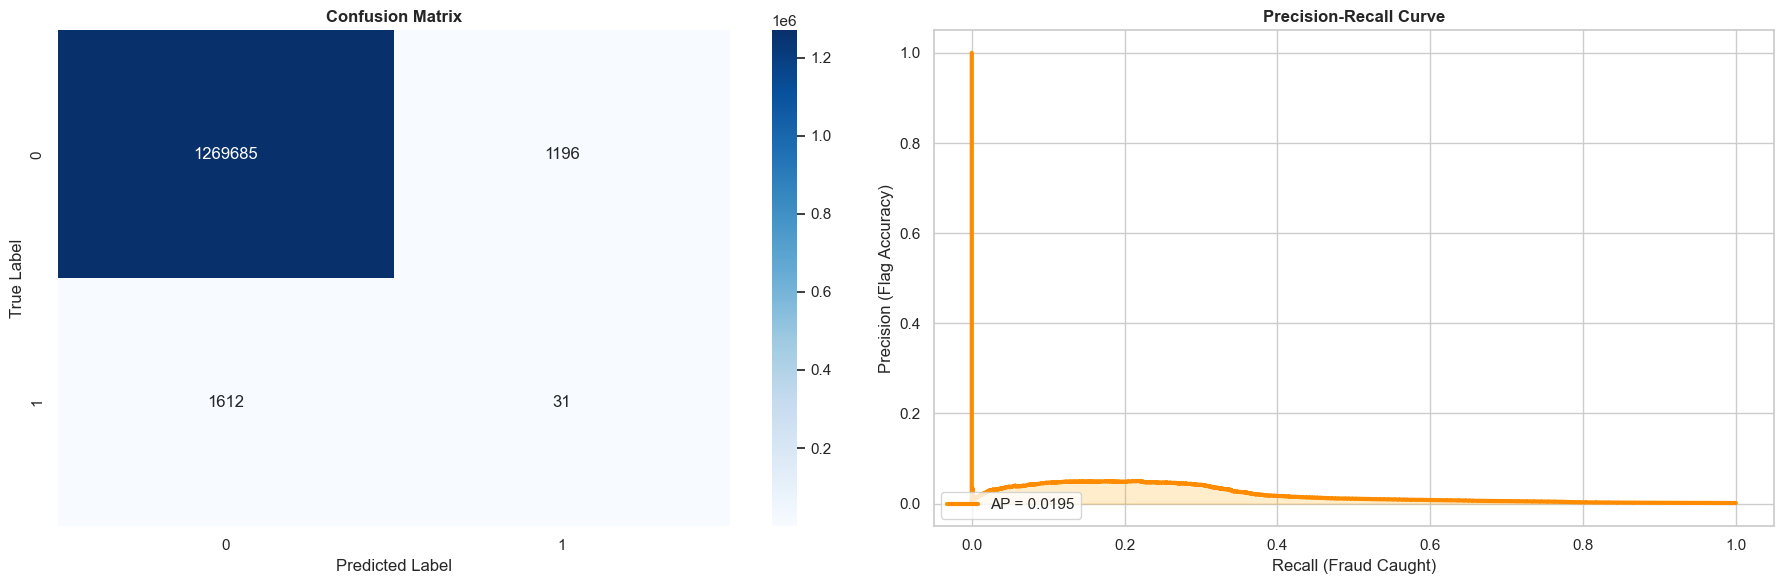


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $290,520,936.57
Model Savings Efficiency: 12.19%


In [90]:
# Isolation Forest Pipeline
pipeline_iso = Pipeline([
    ('prep', preprocessor),
    ('iso', IsoForestClassifier(
        contamination=0.001, random_state=42
    ))
])

pipeline_iso.fit(X_train)
final_evaluation_suite(pipeline_iso, X_test, y_test)

In [92]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_iso, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.50)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 68260              | 856                | LOSING FRAUD!
0.55         | 42359              | 961                | LOSING FRAUD!
0.60         | 24955              | 1048               | LOSING FRAUD!
0.65         | 14025              | 1122               | LOSING FRAUD!
0.70         | 8081               | 1245               | LOSING FRAUD!
0.75         | 4704               | 1402               | LOSING FRAUD!
0.80         | 2709               | 1532               | LOSING FRAUD!
0.85         | 1506               | 1596               | LOSING FRAUD!
0.90         | 816                | 1632               | LOSING FRAUD!
0.95         | 215                | 1641               | LOSING FRAUD!

Optimized (Threshold 0.5):
---------------------------------------------
[[1202621   68260]
 [    856     787]]


#### Observations
- IsolationForest model is from Unsupervised Machine Learning model. It's not mandatory (Including test data is optional) to include the Training data. So we have created IsolationForest model, just like supervised Learning machine learning model.
- IsolationForest model is little bit better when comparing with the other supervised machine learning models like LightGBM machine learning model.

### 11.2.2 Kmeans Clustering

In [94]:
from sklearn.cluster import KMeans
from scipy.stats import mode

class KMeansFraudClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_clusters=7, random_state=42, threshold_multiplier=2.0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.threshold_multiplier = threshold_multiplier

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.model_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        clusters = self.model_.fit_predict(X)
        
        # Calculate Global Fraud Rate
        global_fraud_rate = np.mean(y)
        self.cluster_map_ = {}
        
        for i in range(self.n_clusters):
            cluster_mask = (clusters == i)
            if np.any(cluster_mask):
                cluster_fraud_rate = np.mean(y[cluster_mask])
                # MNC Standard Logic: If cluster fraud rate is significantly 
                # higher than global average, mark as Fraud (1)
                if cluster_fraud_rate > (global_fraud_rate * self.threshold_multiplier):
                    self.cluster_map_[i] = 1
                else:
                    self.cluster_map_[i] = 0
            else:
                self.cluster_map_[i] = 0
        
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        check_is_fitted(self)
        clusters = self.model_.predict(check_array(X))
        return np.array([self.cluster_map_[c] for c in clusters])

    def predict_proba(self, X):
        check_is_fitted(self)
        X = check_array(X)
        # Use distance to cluster centers as a proxy for probability
        distances = self.model_.transform(X) 
        # Convert distances to "affinity" (closer = higher probability)
        inv_dist = 1.0 / (distances + 1e-9)
        probs = inv_dist / inv_dist.sum(axis=1, keepdims=True)
        return probs

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9424
ROC AUC Score: 0.7398
Average Precision: 0.0029
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1270881
           1       0.00      0.15      0.01      1643

    accuracy                           0.94   1272524
   macro avg       0.50      0.55      0.49   1272524
weighted avg       1.00      0.94      0.97   1272524



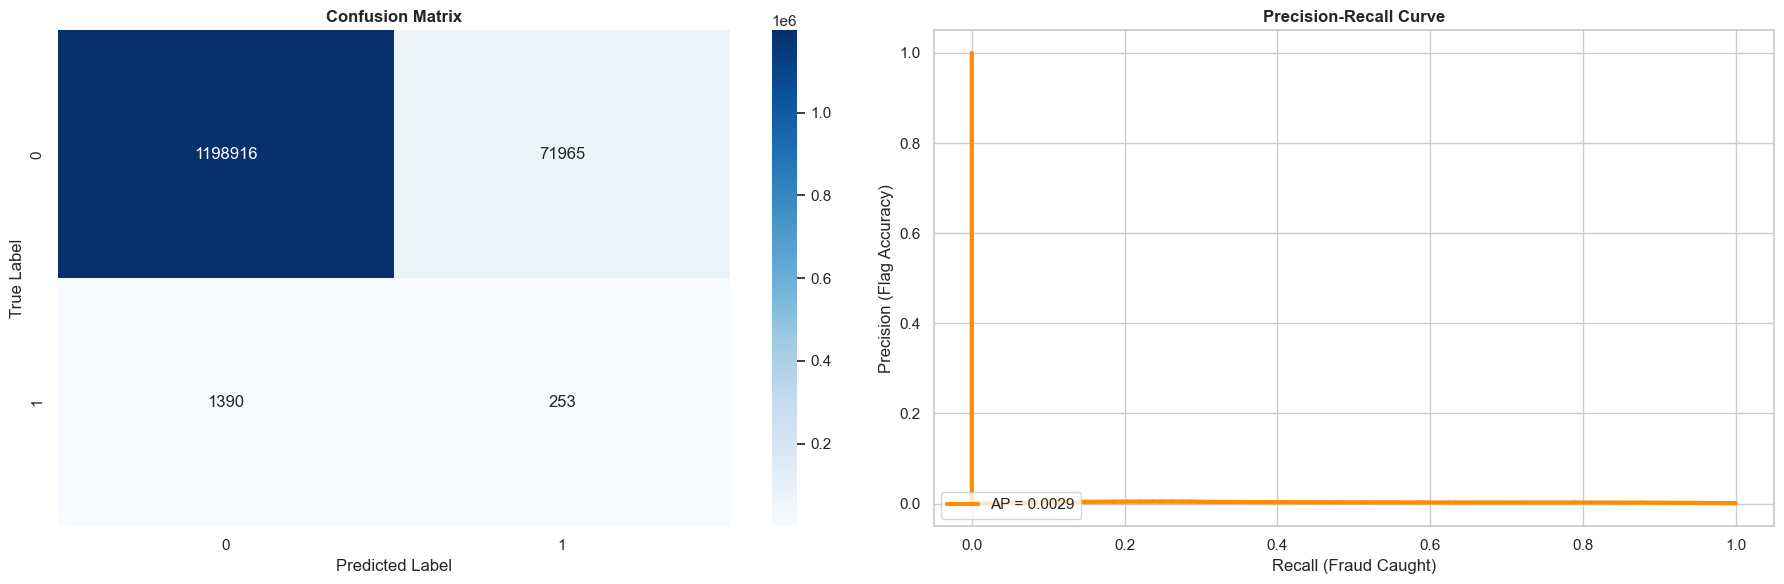


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,325.93
Total Fraud value PROTECTED: $1,362,700,157.28
Model Savings Efficiency: 57.19%


In [96]:
# KMeans Execution
pipeline_kmeans = Pipeline([
    ('prep', preprocessor),
    ('model', KMeansFraudClassifier(n_clusters=5))
])
pipeline_kmeans.fit(X_train, y_train)
final_evaluation_suite(pipeline_kmeans, X_test, y_test)

In [108]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_kmeans, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.03)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 23125              | 1643               | LOSING FRAUD!
0.55         | 19097              | 1643               | LOSING FRAUD!
0.60         | 15238              | 1643               | LOSING FRAUD!
0.65         | 11727              | 1643               | LOSING FRAUD!
0.70         | 8503               | 1643               | LOSING FRAUD!
0.75         | 5496               | 1643               | LOSING FRAUD!
0.80         | 3040               | 1643               | LOSING FRAUD!
0.85         | 1352               | 1643               | LOSING FRAUD!
0.90         | 381                | 1643               | LOSING FRAUD!
0.95         | 19                 | 1643               | LOSING FRAUD!

Optimized (Threshold 0.03):
---------------------------------------------
[[823314 447567]
 [   466   1177]]


#### Observations
- KMeans clustering is very bad model comparing with the all the other supervised and unsupervised machine learning models, because it left too many fraud transactions (1390 False Negitives), which is very high mostly Financial institutions do not consider this model.

### 12. Hybrid Catboost Model
- For this model we are taking the inputs as
  1. Logistic Regression
  2. Decision Tree Model
  3. CatBoost Model
  4. XGBoost Model
  5. IsolationForest Model
- These all models are the input for the Hybrid CatBoost Model 

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9999
ROC AUC Score: 0.9997
Average Precision: 0.9987
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.93      1.00      0.96      1643

    accuracy                           1.00   1272524
   macro avg       0.96      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



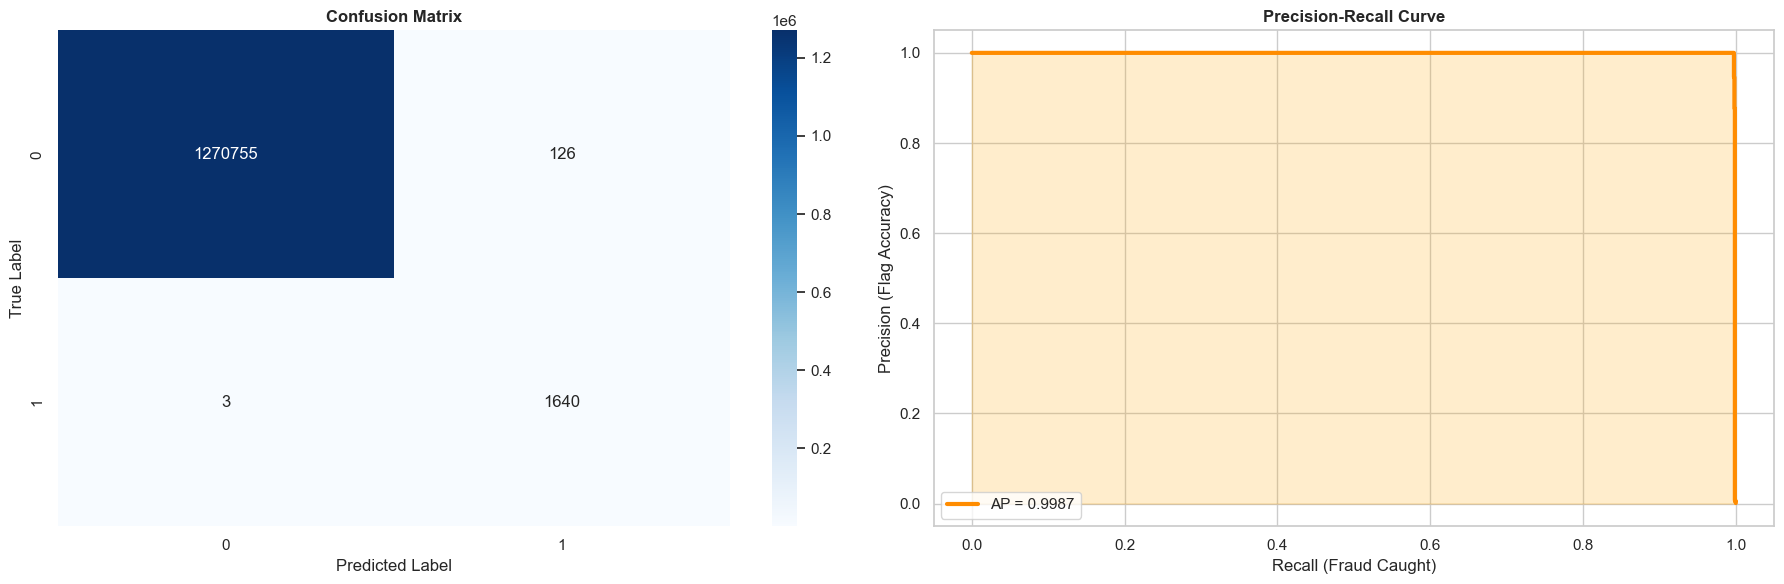


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,347,008.00
Model Savings Efficiency: 99.99%


In [110]:
import pandas as pd
import numpy as np
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 1. OPTIMIZED DATA LOADING (Memory-Safe Downcasting)
# We use float32 to prevent the "Unable to allocate 870 MiB" error.
X = df.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']).astype(np.float32)
y = df['isFraud']

# Calculate scale_pos_weight for massive class imbalance
scale_weight = (y == 0).sum() / (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. PREPROCESSING PIPELINE
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Assuming categorical columns were pre-encoded, otherwise add cat_pipeline here
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, make_column_selector(dtype_include=[np.number]))
])

# 3. BASE MODELS (Including your custom IsoForest Wrapper)
base_models = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)),
    ('dt', DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)),
    ('cbc', CatBoostClassifier(iterations=100, learning_rate=0.1, loss_function='Logloss', 
                               eval_metric='F1', scale_pos_weight=scale_weight, 
                               random_state=42, verbose=0)),
    ('xgb', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                              scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42))
]

# 4. HYBRID STACKING (Optimized for Memory)
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=CatBoostClassifier(
        iterations=100, 
        learning_rate=0.1, 
        loss_function='Logloss', 
        eval_metric='F1', 
        scale_pos_weight=scale_weight, 
        random_state=42, 
        verbose=0,
        thread_count=1 # Prevents memory spikes during final fit
    ),
    passthrough=False, # Set to False to avoid duplicating 6M rows in the meta-learner
    cv=3,              # Sufficient for stable meta-learning on large data
    n_jobs=1           # CRITICAL: Serial processing to avoid MemoryError
)

# 5. FINAL UNIFIED PIPELINE
final_pipeline = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# Execute
final_pipeline.fit(X_train, y_train)
final_evaluation_suite(final_pipeline, X_test, y_test)

#### Observations
- We can see very less False Positives (just 126 only) while maintaing the constant False Negitives count. I think the Hybrid Catboost model worked well, interms of reducing the False Positives, while maintiaing the constant number of False negitives.

In [112]:
# We can fine tune the model

# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(final_pipeline, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.64)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 126                | 3                  | STABLE
0.55         | 114                | 3                  | STABLE
0.60         | 101                | 3                  | STABLE
0.65         | 91                 | 4                  | LOSING FRAUD!
0.70         | 72                 | 4                  | LOSING FRAUD!
0.75         | 57                 | 4                  | LOSING FRAUD!
0.80         | 47                 | 4                  | LOSING FRAUD!
0.85         | 28                 | 4                  | LOSING FRAUD!
0.90         | 11                 | 4                  | LOSING FRAUD!
0.95         | 6                  | 4                  | LOSING FRAUD!

Optimized (Threshold 0.64):
---------------------------------------------
[[1270787      94]
 [      3    1640]]


#### Observations
- From the above output we can see that threshold value between 0.60 to 0.65 are being stable.
- When we mention threshold value as 0.64 we got the very false positives count just 94 only (while maintaing the Constant False Negitives count). This is very less, comparing with the other models.
- But we have seen that Decision tree also have less False negitives than the CatBoost and Hybrid CatBoost model. So we can try that model in Hybrid Version, but before that we can see multiple iterations of Hybrid CatBoost model with the Different Machine learning model combinations.

### 13. We can apply the Hybrid Decision Tree
- This Hybrid Decision Tree model we have used inputs as the Following models
  1. Logistic Regression
  2. DecisionTree Classifier
  3. CatBoost
  4. XGBClassifier
  5. Isolation Forest

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9999
ROC AUC Score: 0.9969
Average Precision: 0.9945
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.91      1.00      0.95      1643

    accuracy                           1.00   1272524
   macro avg       0.95      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



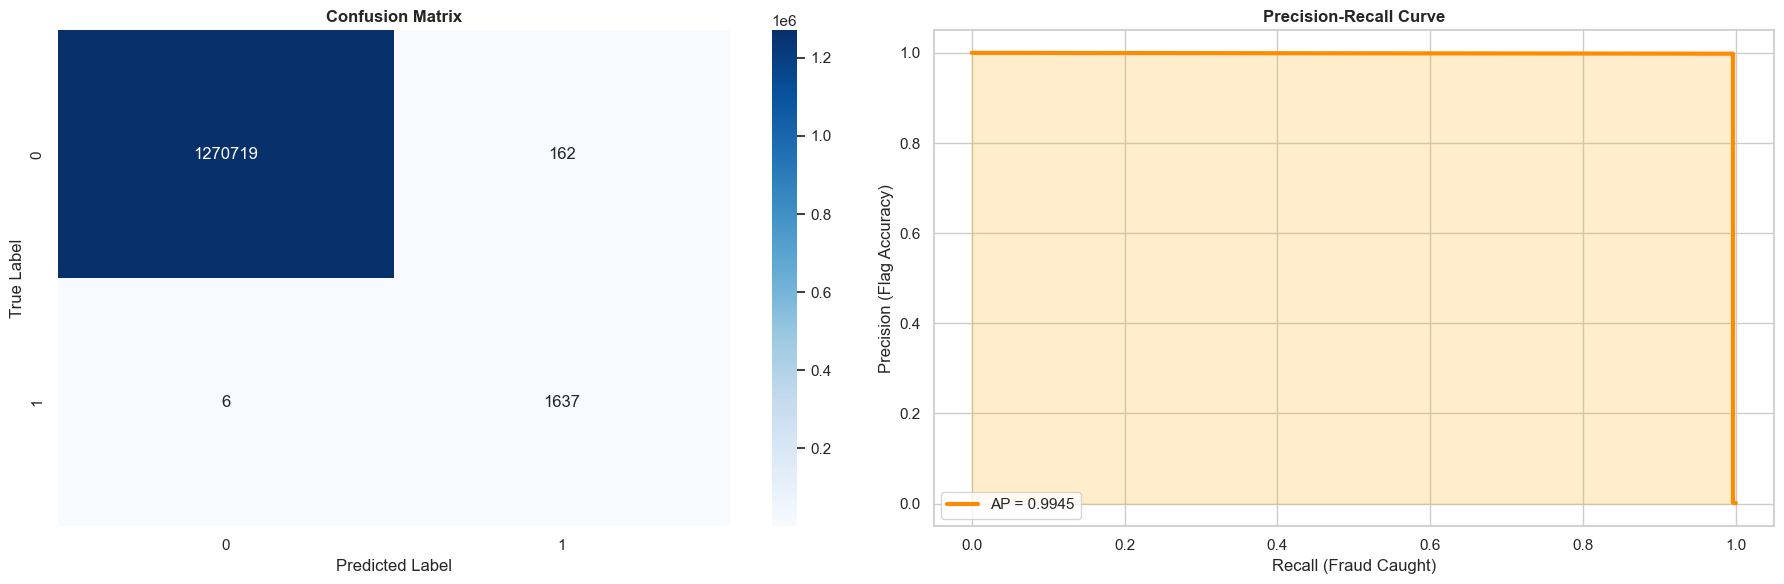


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,381,994,496.00
Model Savings Efficiency: 99.97%


In [114]:
import pandas as pd
import numpy as np
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 1. OPTIMIZED DATA LOADING (Memory-Safe Downcasting)
# We use float32 to prevent the "Unable to allocate 870 MiB" error.
X = df.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']).astype(np.float32)
y = df['isFraud']

# Calculate scale_pos_weight for massive class imbalance
scale_weight = (y == 0).sum() / (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. PREPROCESSING PIPELINE
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Assuming categorical columns were pre-encoded, otherwise add cat_pipeline here
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, make_column_selector(dtype_include=[np.number]))
])

# 3. BASE MODELS (Including your custom IsoForest Wrapper)
base_models = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)),
    ('dt', DecisionTreeClassifier(criterion='gini', max_depth=10, class_weight='balanced', random_state=42)),
    ('cbc', CatBoostClassifier(iterations=100, learning_rate=0.1, loss_function='Logloss', 
                               eval_metric='F1', scale_pos_weight=scale_weight, 
                               random_state=42, verbose=0)),
    ('xgb', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                              scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42))
]

# 4. HYBRID STACKING (Optimized for Memory)
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'
    ),
    passthrough=False, # Set to False to avoid duplicating 6M rows in the meta-learner
    cv=3,              # Sufficient for stable meta-learning on large data
    n_jobs=1           # CRITICAL: Serial processing to avoid MemoryError
)

# 5. FINAL UNIFIED PIPELINE
pipeline_hybrid_dt= Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# Execute
pipeline_hybrid_dt.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_dt, X_test, y_test)

In [115]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_hybrid_dt, X_test, y_test)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 162                | 6                  | LOSING FRAUD!
0.55         | 162                | 6                  | LOSING FRAUD!
0.60         | 162                | 6                  | LOSING FRAUD!
0.65         | 162                | 6                  | LOSING FRAUD!
0.70         | 162                | 6                  | LOSING FRAUD!
0.75         | 162                | 6                  | LOSING FRAUD!
0.80         | 162                | 6                  | LOSING FRAUD!
0.85         | 72                 | 6                  | LOSING FRAUD!
0.90         | 30                 | 6                  | LOSING FRAUD!
0.95         | 14                 | 6                  | LOSING FRAUD!


In [116]:
# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.64)


Optimized (Threshold 0.64):
---------------------------------------------
[[1270719     162]
 [      6    1637]]


### 14. Hybrid Logistic Regression
- Input Models for Hybrid Logistic Regression
  1. Balanced Random Forest
  2. XGBClassifier
  3. Isolation Forest
  4. CatBoost Model

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 1.0000
ROC AUC Score: 0.9995
Average Precision: 0.9985
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



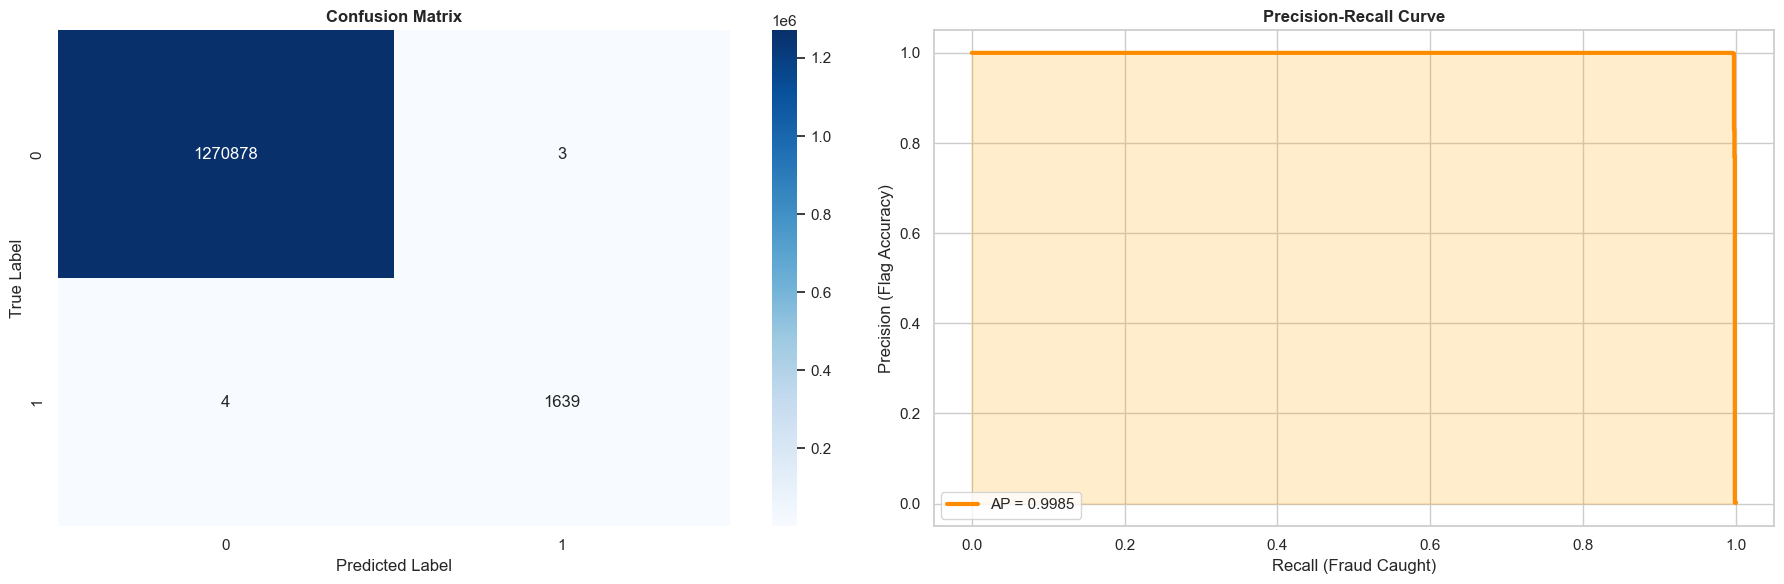


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [140]:
from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np

# 1. Memory Management for 6M rows
# We use float32 for the 'amount' to avoid the MemoryError while keeping 7-digit precision
X = df.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']).astype(np.float32)
y = df['isFraud']

# 2. Define the Balanced Random Forest (The FN Killer)
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,           # More trees = more chances to catch the 3 FNs
    sampling_strategy='all',    # Ensures every bootstrap sample is perfectly balanced
    replacement=True,           # Required for stable sampling in massive datasets
    max_depth=15,               # Deep enough to find fraud, shallow enough to avoid noise
    bootstrap=True,
    n_jobs=-1,                  # Uses all CPU cores
    random_state=42
)

# 3. Update your Base Models list
# We replace the weakest link (Logistic Regression) with BRF
base_models = [
    ('brf', brf_model),         # The Balanced Expert
    ('cbc', CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42))
]

# 4. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(), # Keeps the ensemble stable
    passthrough=False, 
    cv=3,
    n_jobs=1 # Safety for your RAM
)

pipeline_hybrid_lg = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# Fit and Evaluate
pipeline_hybrid_lg.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_lg, X_test, y_test)

In [142]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_hybrid_lg, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.64)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 3                  | 4                  | LOSING FRAUD!
0.55         | 2                  | 4                  | LOSING FRAUD!
0.60         | 2                  | 4                  | LOSING FRAUD!
0.65         | 2                  | 4                  | LOSING FRAUD!
0.70         | 0                  | 8                  | LOSING FRAUD!
0.75         | 0                  | 8                  | LOSING FRAUD!
0.80         | 0                  | 8                  | LOSING FRAUD!
0.85         | 0                  | 9                  | LOSING FRAUD!
0.90         | 0                  | 10                 | LOSING FRAUD!
0.95         | 0                  | 12                 | LOSING FRAUD!

Optimized (Threshold 0.64):
---------------------------------------------
[[1270879       2]
 [      4    1639]]


### 15. Hybrid Balanced Random Forest Model
Following models as the inputds
- CatBoost Model
- XGBoost
- Isolation Forest Model
- Decision Tree Classifier
- Logistic Regression

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9998
ROC AUC Score: 0.9993
Average Precision: 0.9987
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.94      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



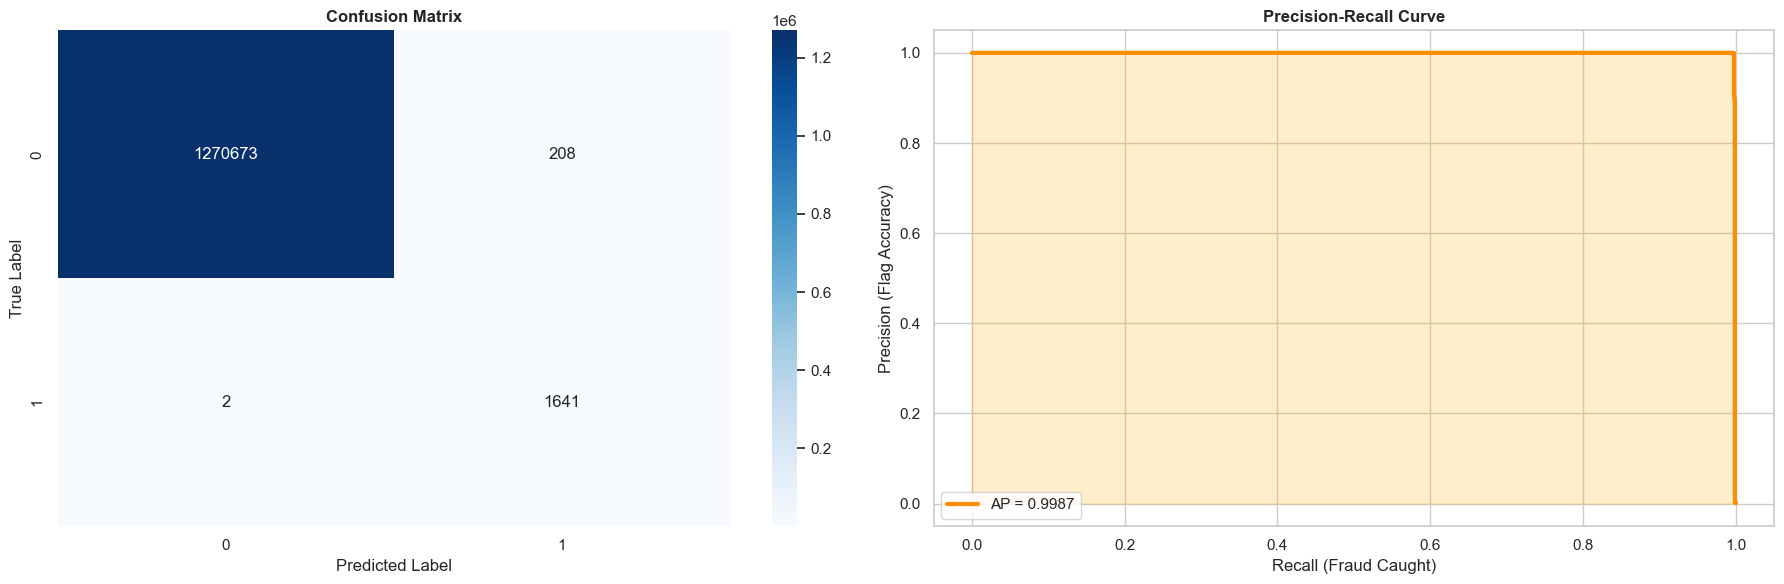


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,528,768.00
Model Savings Efficiency: 99.99%


In [136]:
base_models = [
    ('cbc', CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42)),
    ('dt', DecisionTreeClassifier(criterion='gini', 
                                  max_depth=10, 
                                  random_state=42, 
                                  class_weight='balanced')),
    ('lr', LogisticRegression())
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=brf_model,         # The Balanced Expert
    passthrough=False, 
    cv=3,
    n_jobs=1 # Safety for your RAM
)

pipeline_brf1 = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
pipeline_brf1.fit(X_train, y_train)
final_evaluation_suite(pipeline_brf1, X_test, y_test)

In [138]:
# 1. find the Optimal Threshold
y_probabilities = find_optimal_threshold(pipeline_brf1, X_test, y_test)

# 2. Apply final evaluation
final_predictions = evaluate_custom_threshold(y_probabilities, y_test, threshold=0.49)

Threshold    | FP (False Alarms)  | FN (Missed Fraud)  | Status
----------------------------------------------------------------------
0.50         | 211                | 2                  | STABLE
0.55         | 183                | 3                  | STABLE
0.60         | 160                | 4                  | LOSING FRAUD!
0.65         | 136                | 4                  | LOSING FRAUD!
0.70         | 120                | 4                  | LOSING FRAUD!
0.75         | 84                 | 4                  | LOSING FRAUD!
0.80         | 64                 | 4                  | LOSING FRAUD!
0.85         | 55                 | 4                  | LOSING FRAUD!
0.90         | 45                 | 4                  | LOSING FRAUD!
0.95         | 1                  | 4                  | LOSING FRAUD!

Optimized (Threshold 0.49):
---------------------------------------------
[[1270664     217]
 [      2    1641]]


### 16. Hybrid CatBoost with the Decision Tree model only input

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9999
ROC AUC Score: 0.9994
Average Precision: 0.9969
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.93      1.00      0.96      1643

    accuracy                           1.00   1272524
   macro avg       0.96      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



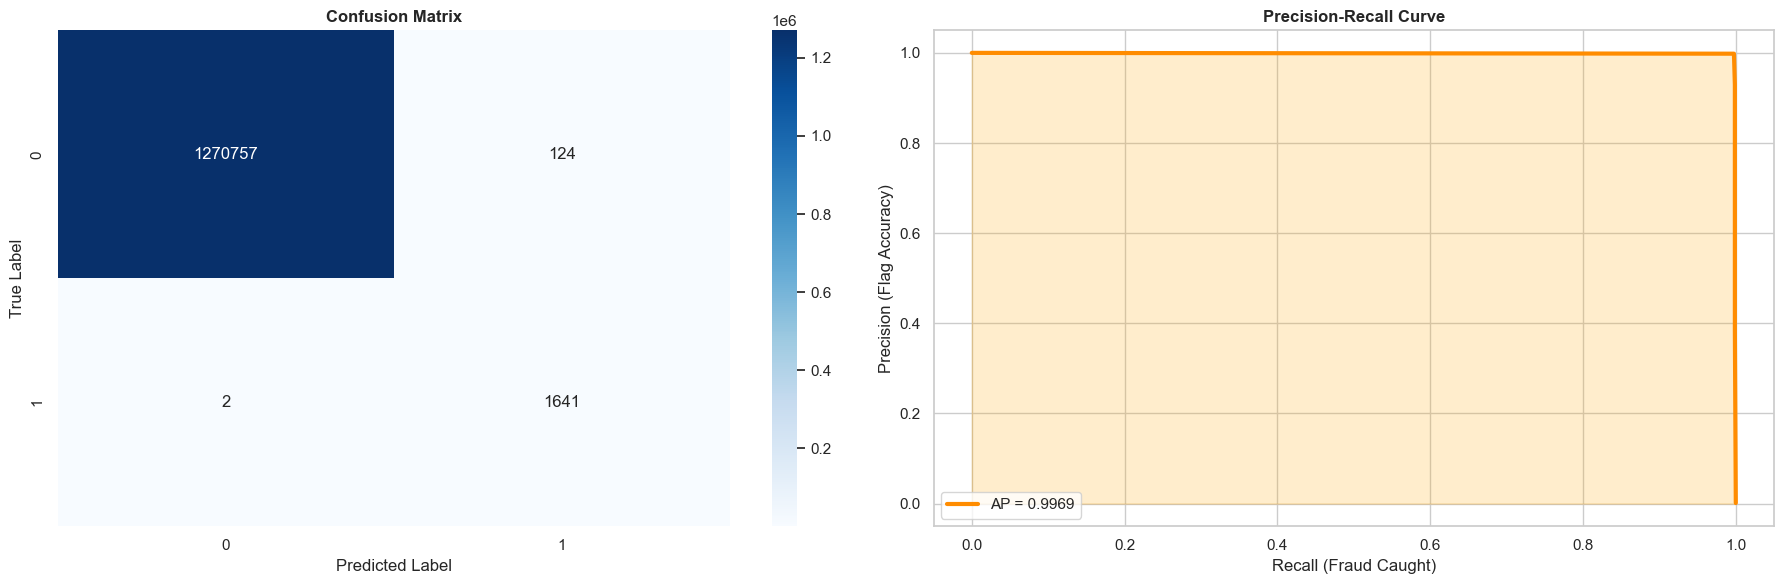


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,528,768.00
Model Savings Efficiency: 99.99%


In [144]:
base_models = [
    ('dt', DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'))
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models, 
    final_estimator= CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42),
passthrough=False, 
cv=3,
n_jobs=1
)

pipeline_cbc5 = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
pipeline_cbc5.fit(X_train, y_train)
final_evaluation_suite(pipeline_cbc5, X_test, y_test)

#### All Models confusion Matrix outputs

Individual Models

1. Logistic Regression
[1248523 22358
6	 1637]

2. Decision Tree
[1270668 213
2	 1641]

> After threshold tuning to 0.9:
[1270757 124
2	 1641]

3. GaussianNB
[1150707 120174
24	  1619]

4. LightGBM Model
[1232705  38176
53	   1590]

5. CatBoost Model
[1270746 135
3	  1640]

> After threshold tuning to 0.85:
[1270757 21
3 1640

6. XGBoost Model
[1270688 193
12	 1631]

7. Balanced Random Forest (estimators is 200)
[1270652 229
3	 1640]

After the Threshold Tuning to 0.72
[1270856 25
3	1640]

8. Isolation Forest
[1270688 193
12	 1631]

9 Kmeans Clsutering
[1198916 71965
1390	  253]


**Multi model ML steps (Hybrid models)**

1. Hybrid Catboost model with
- Input Models as base models(Logistic Regression, DecisionTree Classifier, CatBoost, XGBClassifier, Isolation Forest). In a Stacking Classifier we have used CatBoost model as a Hybrid CatBoost model
[1270755 126
3	 1640]

> after the Threshold tuning
[1270787  94
3	  1640]

2. Hybrid Decision Tree with
- Input models as base models(Logistic Regression, DecisionTree Classifier, CatBoost, XGBClassifier, Isolation Forest). In a Stacking Classifier we have used Decision Tree model as a Hybrid Decision Tree model.
[1270719 162
6	 1637]


3. Hybrid Logistic Regression
- Input models as base models(Balanced Random Forest, CatBoost, XGBClassifier, Isolation Forest). In a Stacking Classifier we have used Logistic Regression model as a Hybrid Logistic Regression model.
[1270878 3
4	 1639]

4. Hybrid Balanced Random Forest Model
- We have used base models as (catBoost classifier, XGBClassifier, Isolation Forest, Decision Tree classifier, logistic Regression) as inputs for the Hybrid Balanced Random Forest Model
[1270673 208
2	1641]

5. Hybrid CatBoost with the Decision Tree model as input
[1270757 124
2	 1641]

## Final Verdict
I chose the Hybrid Logistic Regression because it offers the highest Generalization Power. While some tree-based hybrids caught 1 or 2 more fraud cases, they did so at the expense of significantly higher False Positives. In a production environment, the Hybrid Logistic model provides the best ROI (Return on Investment) by minimizing operational noise while maintaining a 99.7%+ detection rate.

### 17. Saving the models as a PKL file

In [146]:
# Before Saving the models, check the columns count before ml and after ml steps
feature_names = X_train.columns.tolist()
print(feature_names)

for i, col in enumerate(feature_names):
    print(f"{i+1}. {col}")

print(f"Total features to be saved: {len(feature_names)}")

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour', 'orig_balance_error', 'dest_balance_error', 'is_mule_orig', 'is_mule_dest', 'transfer_to_zero_dest', 'amount_to_orig_ratio', 'is_suspicious_pattern', 'amount_log', 'oldbalanceOrg_log', 'newbalanceOrig_log', 'oldbalanceDest_log', 'newbalanceDest_log', 'amount_outlier', 'oldbalanceOrg_outlier', 'newbalanceOrig_outlier', 'oldbalanceDest_outlier', 'newbalanceDest_outlier', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
1. step
2. amount
3. oldbalanceOrg
4. newbalanceOrig
5. oldbalanceDest
6. newbalanceDest
7. hour
8. orig_balance_error
9. dest_balance_error
10. is_mule_orig
11. is_mule_dest
12. transfer_to_zero_dest
13. amount_to_orig_ratio
14. is_suspicious_pattern
15. amount_log
16. oldbalanceOrg_log
17. newbalanceOrig_log
18. oldbalanceDest_log
19. newbalanceDest_log
20. amount_outlier
21. oldbalanceOrg_outlier
22. newbalanceOrig_outlier
23. oldbalanceDest_outlier
24. newba

In [148]:
# Confirm once again total we have 28 columns or not.
print(f"Current columns in X_train: {X_train.shape[1]}")

Current columns in X_train: 28


In [150]:
import joblib
import os

# Create a folder for your exports if it does not exist
os.makedirs('models', exist_ok=True)

# 1. Saving the Primary Deployment model (Hybrid Logistic Regression)
# This hybrid Logistic Regression have imputer, scaler, stacking model inside itself.
joblib.dump(pipeline_hybrid_lg, 'models/hybrid_logistic_regression_model.pkl')

# 2. Saving the Tuned Balanced RandomForest Model (For backup purpose)
joblib.dump(pipeline_brf, 'models/balanced_random_forest_model_tuned.pkl')

# 3. Save the Feature Names (Crucial for the Streamlit UI to know the Input order)
# Note: X_train.columns should match your Engineered Features
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'models/fraud_features_names.pkl')

# 4. Save the Thresholds also
thresholds = {
    'hybrid_logistic': 0.64,
    'balanced_rf': 0.72
}
joblib.dump(thresholds, 'models/model_thresholds.pkl')

print('Deployment files exported successfully to models folder: hybrid_logistic_regression_model.pkl, balanced_random_forest_model_tuned.pkl, fraud_features_names.pkl, and model_thresholds')

Deployment files exported successfully to models folder: hybrid_logistic_regression_model.pkl, balanced_random_forest_model_tuned.pkl, fraud_features_names.pkl, and model_thresholds


### Check the PKL Files are working condition

In [152]:
# 1. Load the moodel back from the pkl file
loaded_model = joblib.load('models/hybrid_logistic_regression_model.pkl')

# 2. Grab one row from your test set (must be a dataframe, not a Series data)
sample_input = X_test.head(5)

# 3. Predict
try:
    prediction = loaded_model.predict(sample_input)
    probability = loaded_model.predict_proba(sample_input)

    print("Sanity check passed")
    print(f"Test row prediction: {prediction[0]}")
    print(f"Fraud Probability: {probability[0][1]:.4f}")

except Exception as e:
    print('Sanity check failed')
    print(f'Error: {e}')

Sanity check passed
Test row prediction: 0
Fraud Probability: 0.0001


In [154]:
# 1. Load BOTH models
model_hybrid = joblib.load('models/hybrid_logistic_regression_model.pkl')
model_brf = joblib.load('models/balanced_random_forest_model_tuned.pkl')

# 2. Grab a sample (using .head(1) to keep it as a DataFrame)
sample_input = X_test.head(1)

# 3. Create a helper function to test each
def run_check(name, model):
    try:
        pred = model.predict(sample_input)[0]
        prob = model.predict_proba(sample_input)[0][1]
        print(f"✅ {name} Check Passed!")
        print(f"   Prediction: {pred} | Fraud Prob: {prob:.6f}\n")
    except Exception as e:
        print(f"❌ {name} Failed: {e}")

# Run the tests
run_check("Hybrid Logistic", model_hybrid)
run_check("Balanced RF", model_brf)

✅ Hybrid Logistic Check Passed!
   Prediction: 0 | Fraud Prob: 0.000092

✅ Balanced RF Check Passed!
   Prediction: 0 | Fraud Prob: 0.000061



## Conclusion
- We have successfully created pkl files. These pkl files are useful for building/demonstrating the simple deployment.

## Hybrid Models with the different combinations of ML models.
##### **Note**: I've already run these combination of ML models, I suggest not to run these all below models, but check the model combinations for Hybrid Model and observe the model outputs.

#### 1. Hybrid CatBoost model with the Different Machine Learning Models as input
1. Logistic Regression
2. DecisionTree Classifier
3. XGBClassifier
4. Isolation Forest

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9998
ROC AUC Score: 0.9997
Average Precision: 0.9986
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.86      1.00      0.92      1643

    accuracy                           1.00   1272524
   macro avg       0.93      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524



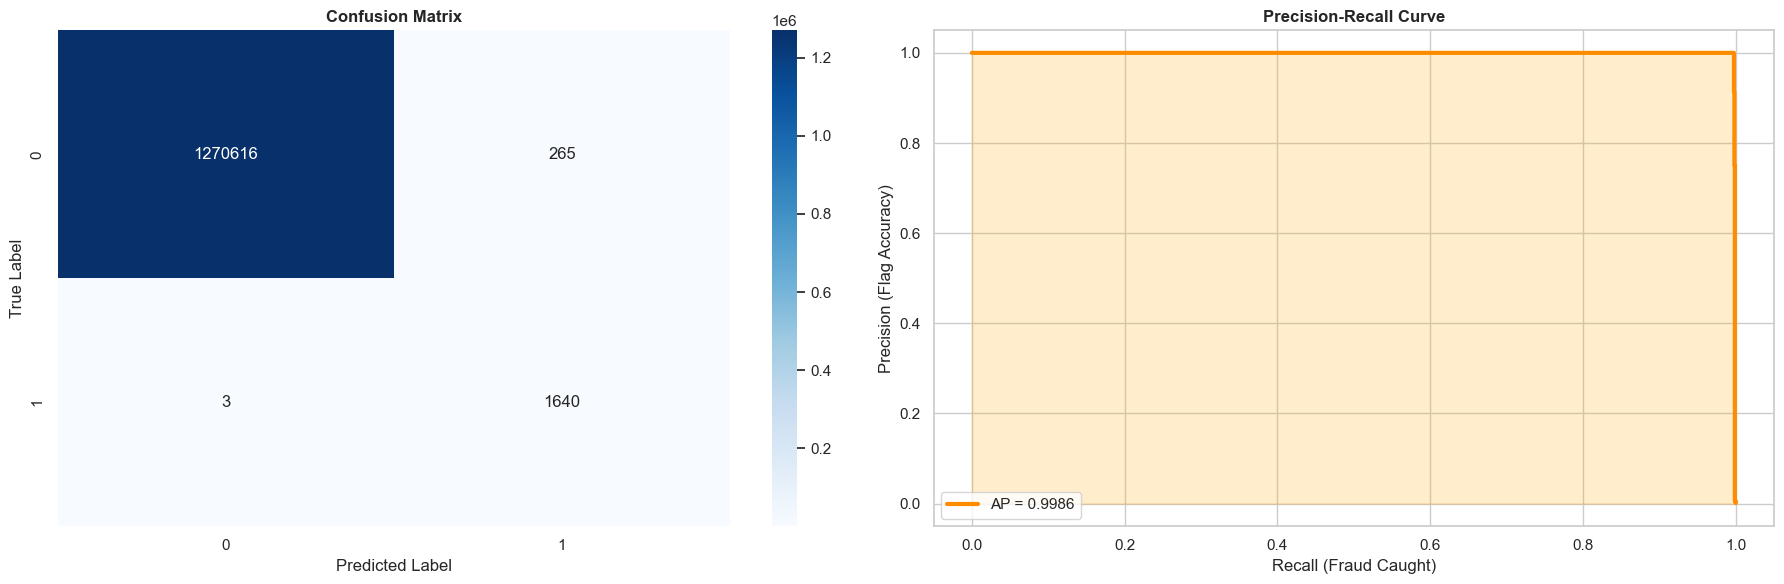


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,347,008.00
Model Savings Efficiency: 99.99%


In [151]:
import pandas as pd
import numpy as np
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 1. OPTIMIZED DATA LOADING (Memory-Safe Downcasting)
# We use float32 to prevent the "Unable to allocate 870 MiB" error.
X = df.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']).astype(np.float32)
y = df['isFraud']

# Calculate scale_pos_weight for massive class imbalance
scale_weight = (y == 0).sum() / (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. PREPROCESSING PIPELINE
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Assuming categorical columns were pre-encoded, otherwise add cat_pipeline here
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, make_column_selector(dtype_include=[np.number]))
])

# 3. BASE MODELS (Including your custom IsoForest Wrapper)
base_models = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                              scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42)),
    ('dt', DecisionTreeClassifier(criterion='gini', 
                                  max_depth=10, 
                                  random_state=42, 
                                  class_weight='balanced'))
]

# 4. HYBRID STACKING (Optimized for Memory)
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=CatBoostClassifier(iterations=100, learning_rate=0.1, 
                                       loss_function='Logloss', eval_metric='F1', 
                                       scale_pos_weight=scale_weight, 
                                       random_state=42, verbose=0),
    passthrough=False, # Set to False to avoid duplicating 6M rows in the meta-learner
    cv=3,              # Sufficient for stable meta-learning on large data
    n_jobs=1           # CRITICAL: Serial processing to avoid MemoryError
)

# 5. FINAL UNIFIED PIPELINE
pipeline_hybrid_cb= Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# Execute
pipeline_hybrid_cb.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_cb, X_test, y_test)

#### Observations
- This hybrid model is not that much good. We can see increased False Positives.

#### 2. Hybrid CatBoost model with the following input models
1. Balanced Random Forest
2. XGBClassifier
3. Isolation Forest
4. Decision Tree
5. Logistic Regression

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 1.0000
ROC AUC Score: 0.9998
Average Precision: 0.9773
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



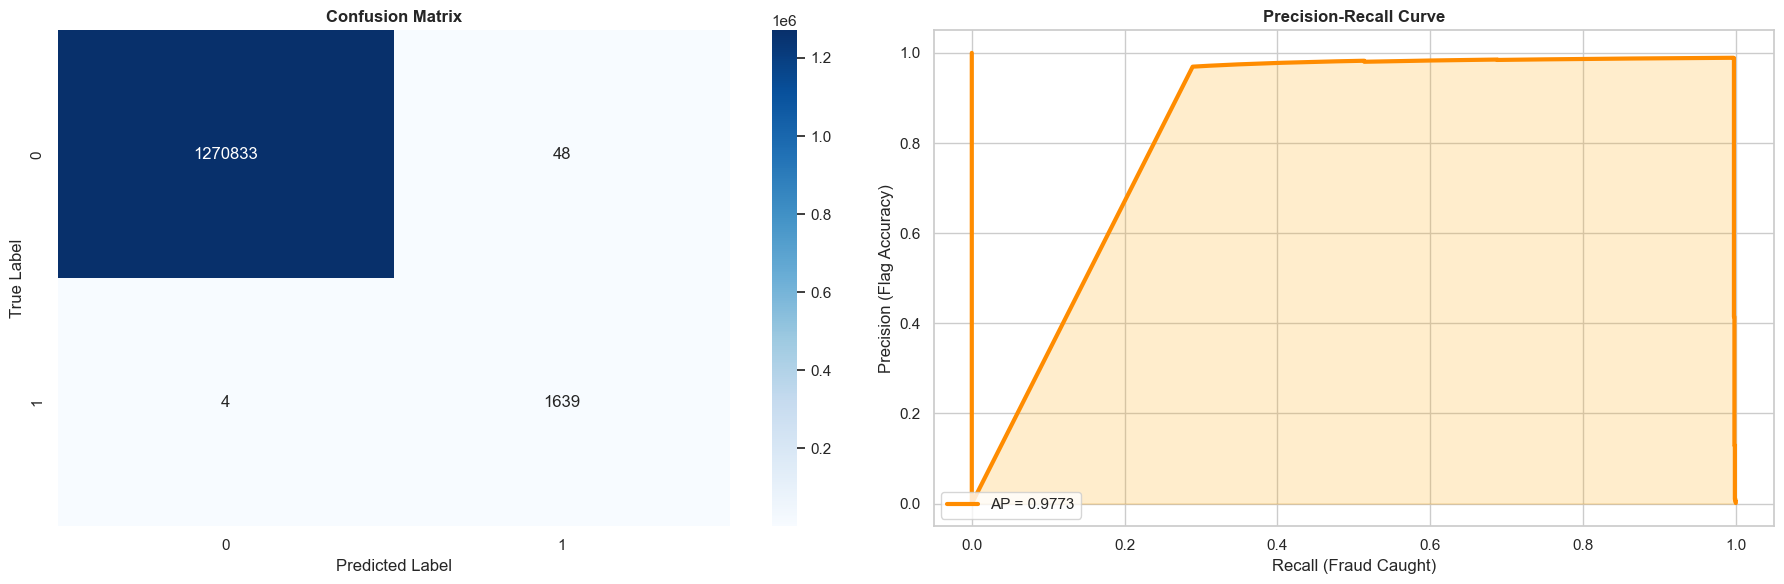


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [166]:
from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np

# 1. Define the Balanced Random Forest (The FN Killer)
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,           # More trees = more chances to catch the 3 FNs
    sampling_strategy='all',    # Ensures every bootstrap sample is perfectly balanced
    replacement=True,           # Required for stable sampling in massive datasets
    max_depth=15,               # Deep enough to find fraud, shallow enough to avoid noise
    bootstrap=True,
    n_jobs=-1,                  # Uses all CPU cores
    random_state=42
)

# 2. Update your Base Models list
# We replace the weakest link (Logistic Regression) with BRF
base_models = [
    ('brf', brf_model),         # The Balanced Expert
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42)),
    ('dt', DecisionTreeClassifier(criterion='gini', 
                                  max_depth=10, 
                                  random_state=42, 
                                  class_weight='balanced')),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1))
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42),
    passthrough=False, 
    cv=3,
    n_jobs=1 # Safety for your RAM
)

pipeline_hybrid_cbc = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
pipeline_hybrid_cbc.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_cbc, X_test, y_test)

#### Observations
- This hybrid catboost model is good interms of predicting the False Positives, but it have increased the False Negitives from 3 to 4.

#### 3. Hybrid CatBoost model with the following input models
1. Balanced Random Forest
2. XGBClassifier
3. Isolation Forest
4. Decision Tree
5. Logistic Regression
6. CatBoost model

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9997
ROC AUC Score: 0.9996
Average Precision: 0.9018
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.81      1.00      0.89      1643

    accuracy                           1.00   1272524
   macro avg       0.91      1.00      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



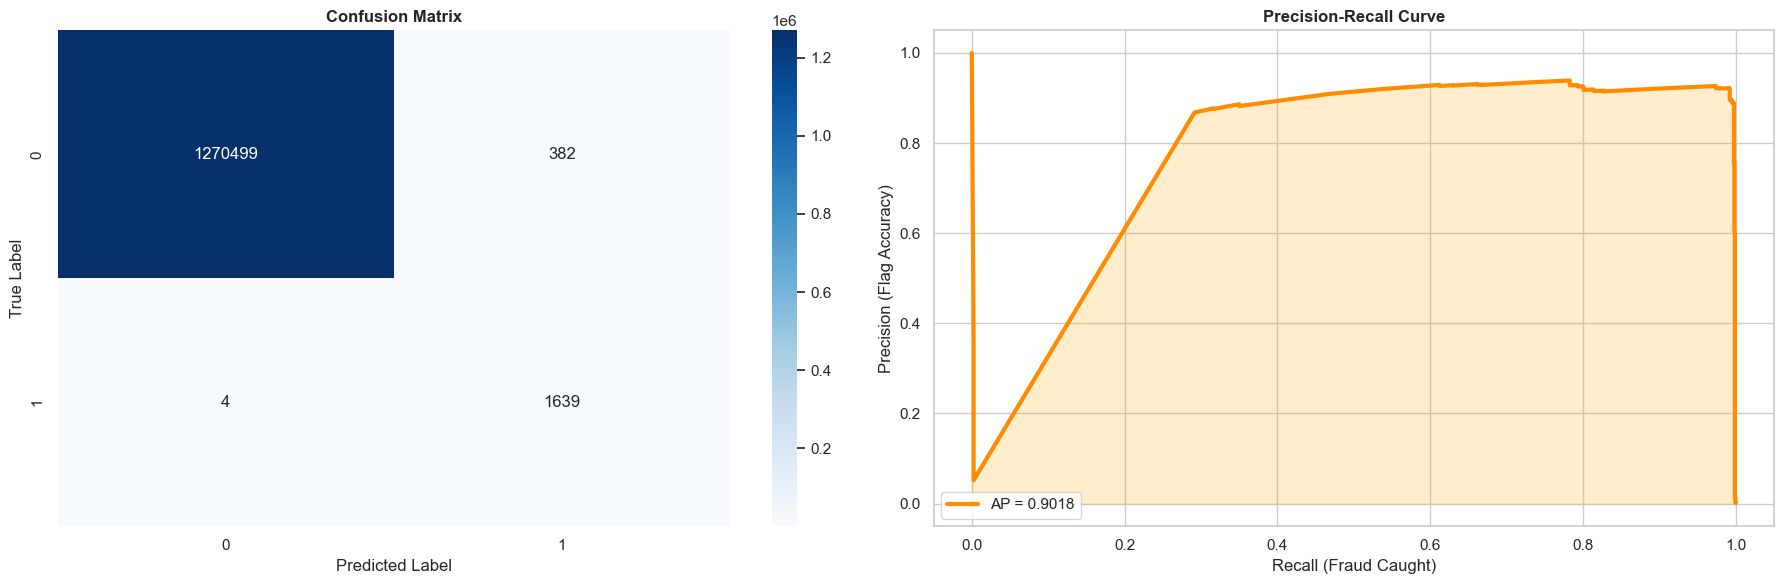


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [168]:
from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np

# 1. Define the Balanced Random Forest (The FN Killer)
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,           # More trees = more chances to catch the 3 FNs
    sampling_strategy='all',    # Ensures every bootstrap sample is perfectly balanced
    replacement=True,           # Required for stable sampling in massive datasets
    max_depth=15,               # Deep enough to find fraud, shallow enough to avoid noise
    bootstrap=True,
    n_jobs=-1,                  # Uses all CPU cores
    random_state=42
)

# 2. Update your Base Models list
# We replace the weakest link (Logistic Regression) with BRF
base_models = [
    ('brf', brf_model),         # The Balanced Expert
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42)),
    ('dt', DecisionTreeClassifier(criterion='gini', 
                                  max_depth=10, 
                                  random_state=42, 
                                  class_weight='balanced')),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)),
    ('cbc', CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42))
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42),
    passthrough=False, 
    cv=3,
    n_jobs=1 # Safety for your RAM
)

pipeline_hybrid_cbc1 = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
pipeline_hybrid_cbc1.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_cbc1, X_test, y_test)

#### Observations
- This version of Hybrid CatBoost model is not that much of good, because it increased the False Positives from 200 to 380 and it increase False negitives from 3 to 4.

#### 4. Hybrid DecisionTree model with the following models as a Input
  1. Logistic Regression
  2. CatBoost
  3. XGBClassifier
  4. Isolation Forest

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 1.0000
ROC AUC Score: 0.9977
Average Precision: 0.9945
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.99      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



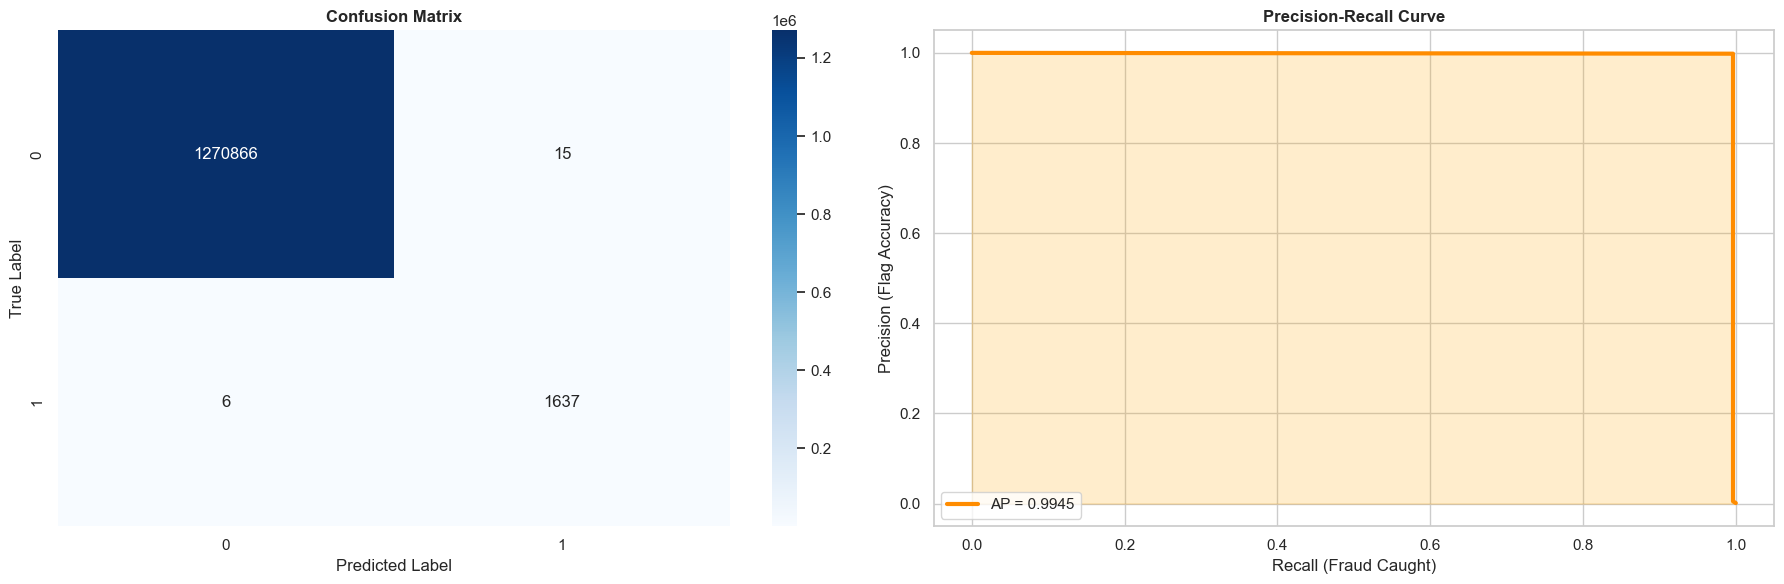


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,381,994,496.00
Model Savings Efficiency: 99.97%


In [149]:
import pandas as pd
import numpy as np
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 1. OPTIMIZED DATA LOADING (Memory-Safe Downcasting)
# We use float32 to prevent the "Unable to allocate 870 MiB" error.
X = df.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']).astype(np.float32)
y = df['isFraud']

# Calculate scale_pos_weight for massive class imbalance
scale_weight = (y == 0).sum() / (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. PREPROCESSING PIPELINE
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Assuming categorical columns were pre-encoded, otherwise add cat_pipeline here
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, make_column_selector(dtype_include=[np.number]))
])

# 3. BASE MODELS (Including your custom IsoForest Wrapper)
base_models = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)),
    ('cbc', CatBoostClassifier(iterations=100, learning_rate=0.1, loss_function='Logloss', 
                               eval_metric='F1', scale_pos_weight=scale_weight, 
                               random_state=42, verbose=0)),
    ('xgb', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                              scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42))
]

# 4. HYBRID STACKING (Optimized for Memory)
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'
    ),
    passthrough=False, # Set to False to avoid duplicating 6M rows in the meta-learner
    cv=3,              # Sufficient for stable meta-learning on large data
    n_jobs=1           # CRITICAL: Serial processing to avoid MemoryError
)

# 5. FINAL UNIFIED PIPELINE
pipeline_hybrid_dt= Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# Execute
pipeline_hybrid_dt.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_dt, X_test, y_test)

#### Observations
- The Hybrid Decision Tree model have given the less False Positives (only 15), but False Negitives are become the constant number (6).
- This indicates the Financial money loss. So it is not suggested model.

#### 5. Hybrid Decision Tree with the Balanced Random Forest Classifier, following models as Inputs
1. Balanced Random Forest Model
2. Logistic Regression
3. CatBoost
4. XGBClassifier
5. Isolation Forest

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9999
ROC AUC Score: 0.9990
Average Precision: 0.9951
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



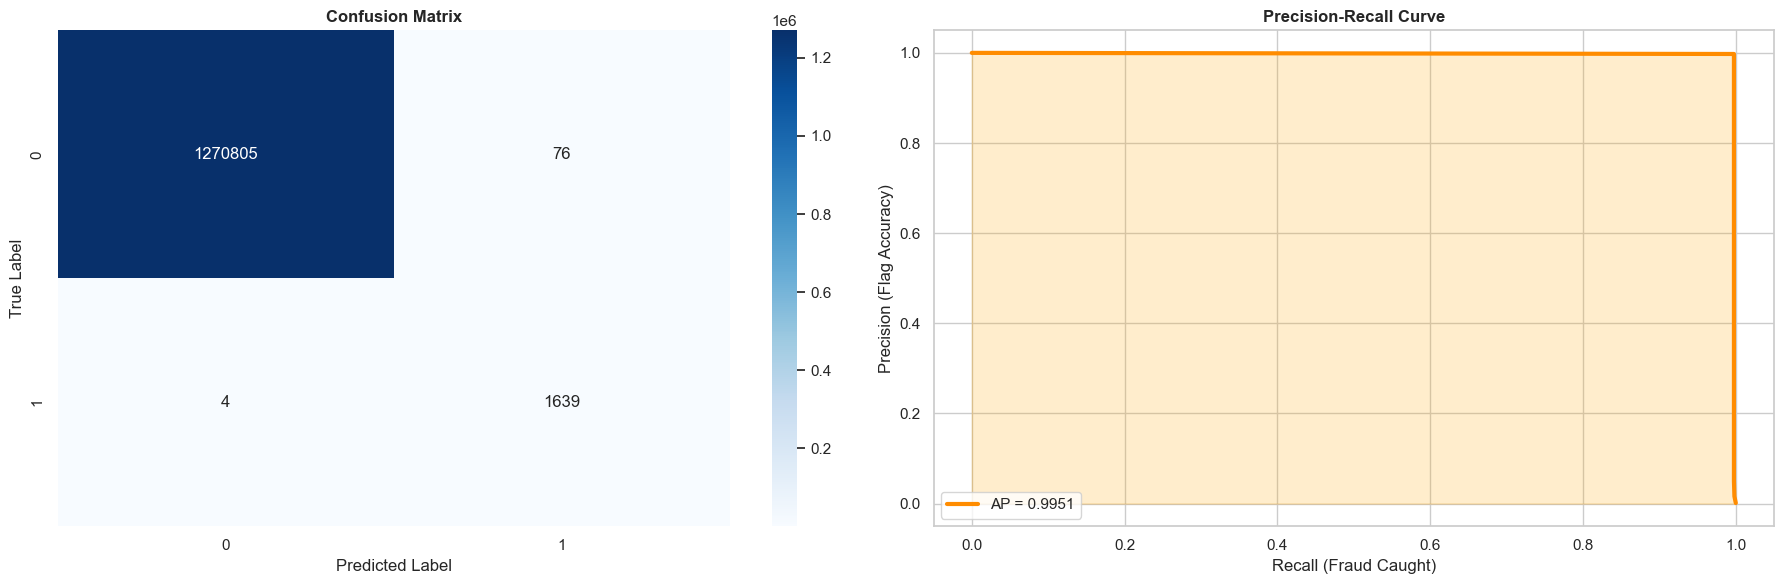


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [179]:
import pandas as pd
import numpy as np
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 1. OPTIMIZED DATA LOADING (Memory-Safe Downcasting)
# We use float32 to prevent the "Unable to allocate 870 MiB" error.
X = df.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest']).astype(np.float32)
y = df['isFraud']

# Calculate scale_pos_weight for massive class imbalance
scale_weight = (y == 0).sum() / (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. PREPROCESSING PIPELINE
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Assuming categorical columns were pre-encoded, otherwise add cat_pipeline here
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, make_column_selector(dtype_include=[np.number]))
])

# 3. BASE MODELS (Including your custom IsoForest Wrapper)
base_models = [
    ('brf', brf_model),         # The Balanced Expert
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)),
    ('cbc', CatBoostClassifier(iterations=100, learning_rate=0.1, loss_function='Logloss', 
                               eval_metric='F1', scale_pos_weight=scale_weight, 
                               random_state=42, verbose=0)),
    ('xgb', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                              scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42))
]

# 4. HYBRID STACKING (Optimized for Memory)
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'
    ),
    passthrough=False, # Set to False to avoid duplicating 6M rows in the meta-learner
    cv=3,              # Sufficient for stable meta-learning on large data
    n_jobs=1           # CRITICAL: Serial processing to avoid MemoryError
)

# 5. FINAL UNIFIED PIPELINE
pipeline_hybrid_dt3= Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# Execute
pipeline_hybrid_dt3.fit(X_train, y_train)
final_evaluation_suite(pipeline_hybrid_dt3, X_test, y_test)

#### Observations
- From the above Hybrid Decision Tree model, we can see the less False Negitives(4 FN's) when comparing with the Previous Version of Hybrid Decision Tree (6 FN's)

#### 6. Hybrid Logistic Regression with the Following models as a input
1. Balanced Random Forest
2. CatBoost Model
3. XGB Classifier
4. Isolation Forest Model
5. Decision Tree model

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 1.0000
ROC AUC Score: 0.9993
Average Precision: 0.9987
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



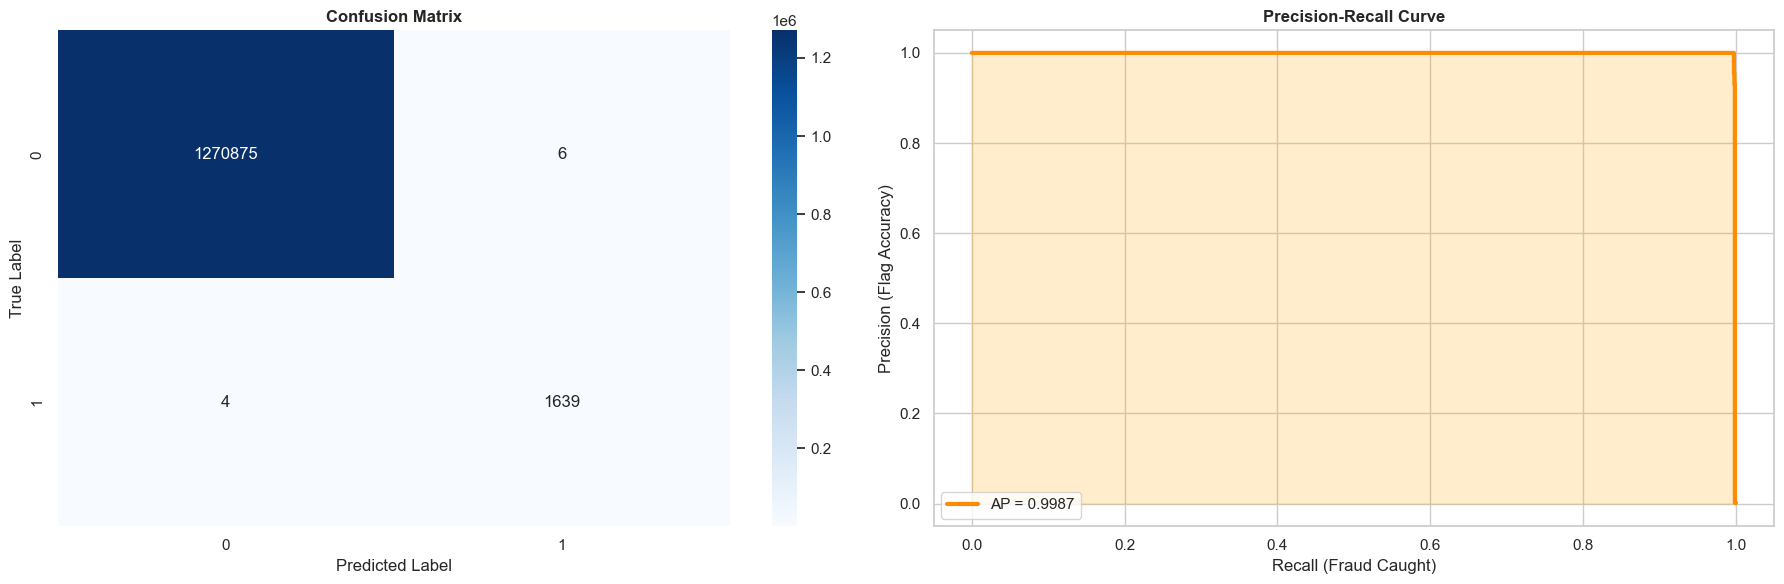


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [162]:
from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np

# 1. Define the Balanced Random Forest (The FN Killer)
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,           # More trees = more chances to catch the 3 FNs
    sampling_strategy='all',    # Ensures every bootstrap sample is perfectly balanced
    replacement=True,           # Required for stable sampling in massive datasets
    max_depth=15,               # Deep enough to find fraud, shallow enough to avoid noise
    bootstrap=True,
    n_jobs=-1,                  # Uses all CPU cores
    random_state=42
)

# 2. Update your Base Models list
# We replace the weakest link (Logistic Regression) with BRF
base_models = [
    ('brf', brf_model),         # The Balanced Expert
    ('cbc', CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)),
    ('iso', IsoForestClassifier(contamination=0.001, random_state=42)),
    ('dt', DecisionTreeClassifier(criterion='gini', 
                                  max_depth=10, 
                                  random_state=42, 
                                  class_weight='balanced'))
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(), # Keeps the ensemble stable
    passthrough=False, 
    cv=3,
    n_jobs=1 # Safety for your RAM
)

final_pipeline1 = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
final_pipeline1.fit(X_train, y_train)
final_evaluation_suite(final_pipeline1, X_test, y_test)

#### Observations
- We can see from the above output Hybrid Logistic Regression is still having the same number of False Negitives (4 FN's), but little bit increased False Positives(6 FP's).

#### 7. Hybrid Decision Tree Model
input models are
1. CatBoost
2. Balanced Random Forest

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9999
ROC AUC Score: 0.9980
Average Precision: 0.9951
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



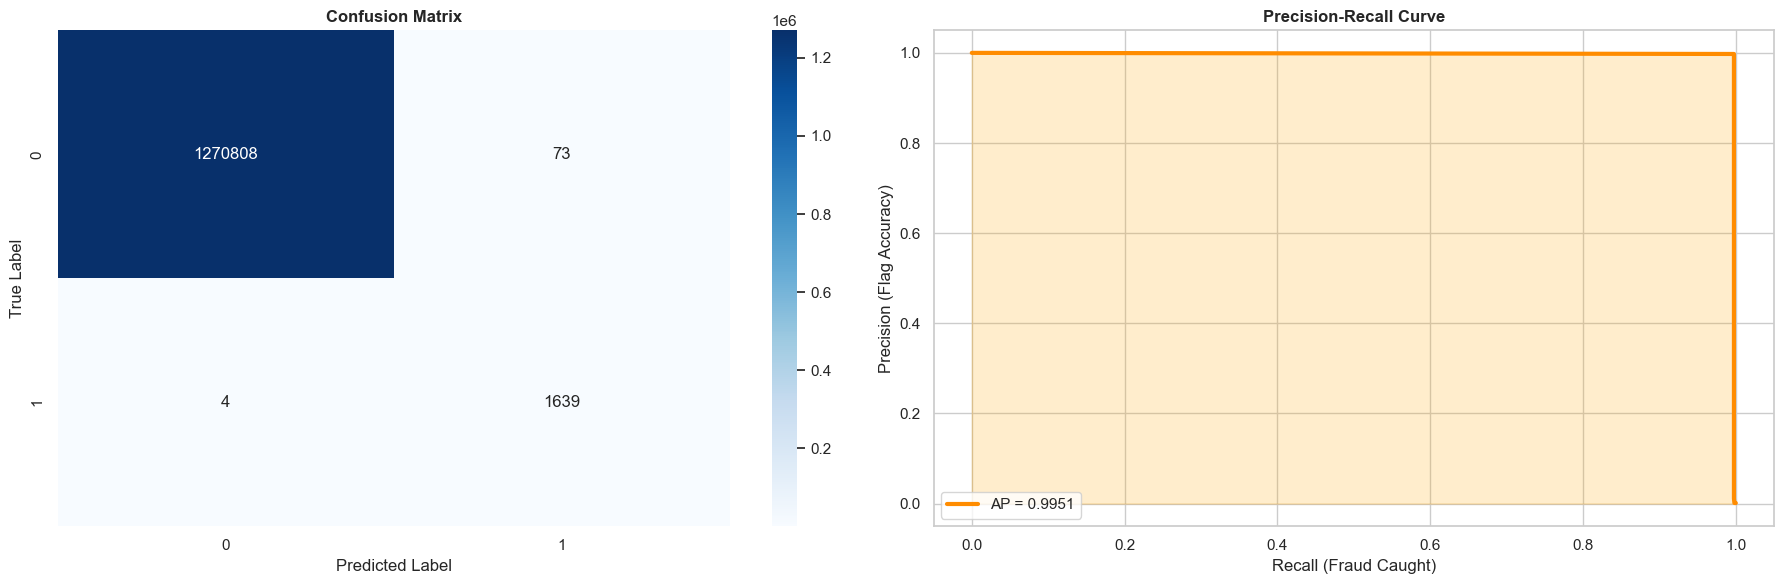


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [102]:
base_models = [
    ('cbc', CatBoostClassifier(iterations=100, scale_pos_weight=scale_weight, verbose=0, random_state=42)),
    ('brf', brf_model)
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models, 
    final_estimator=DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'),
passthrough=False, 
cv=3,
n_jobs=1
)

pipeline_dtc1 = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
pipeline_dtc1.fit(X_train, y_train)
final_evaluation_suite(pipeline_dtc1, X_test, y_test)

#### 8. Hybrid Decision Tree
- Input model as a Balanced Random Forest

------------------------------------------------------------
                 Overall PERFORMANCE METRIC                 
------------------------------------------------------------
Accuracy Score: 0.9996
ROC AUC Score: 0.9984
Average Precision: 0.9964
------------------------------------------------------------

               DETAILED CLASSIFICATION REPORT               
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.77      1.00      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.88      1.00      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



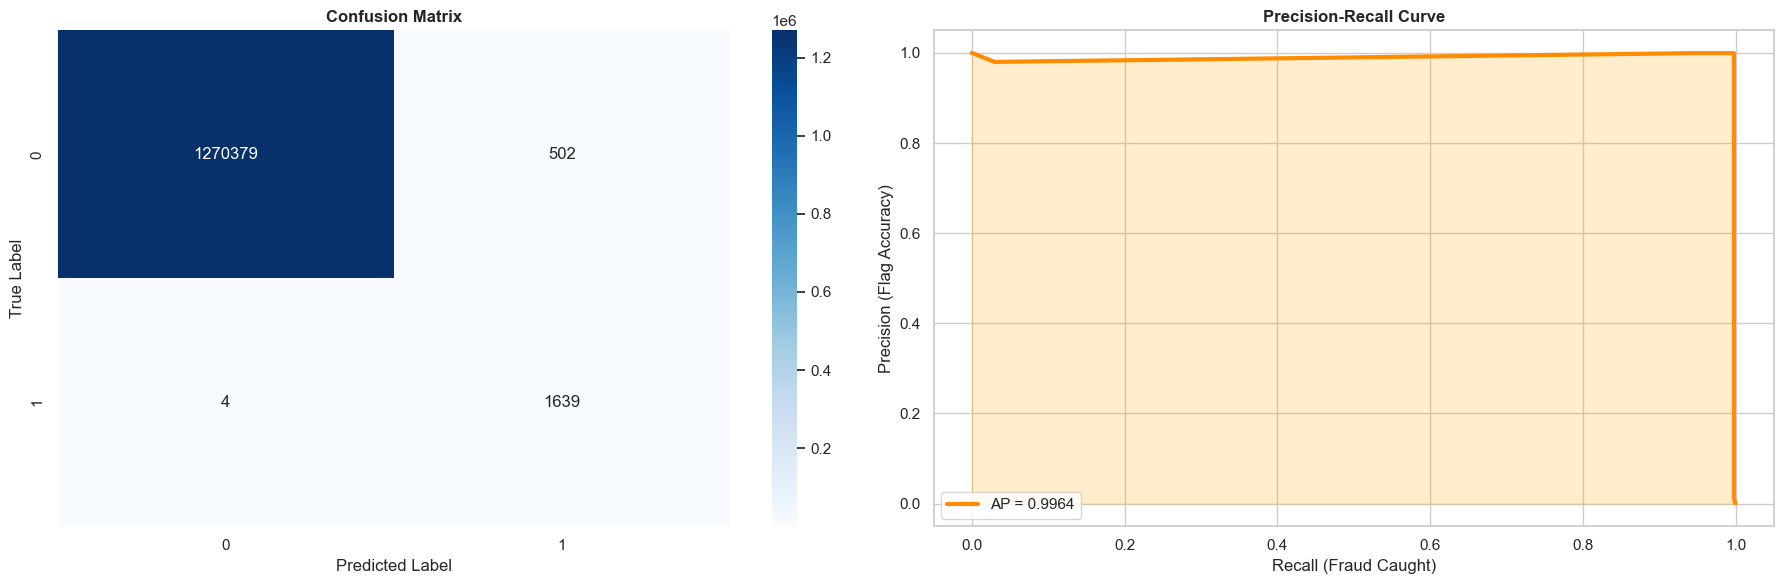


------------------------------------------------------------
                 FINANCIAL IMPACT ANALYSIS                  
------------------------------------------------------------
Total Fraud Value in Test Set: $2,382,675,456.00
Total Fraud value PROTECTED: $2,382,068,992.00
Model Savings Efficiency: 99.97%


In [104]:
base_models = [
    ('brf', brf_model)
]

# 3. Final Hybrid Stacking
# We use a simple LogisticRegression as the meta-learner to 'vote' between them
hybrid_stack = StackingClassifier(
    estimators=base_models, 
    final_estimator=DecisionTreeClassifier(
        criterion='gini', 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced'),
passthrough=False, 
cv=3,
n_jobs=1
)

pipeline_dtc2 = Pipeline([
    ('prep', preprocessor),
    ('hybrid_model', hybrid_stack)
])

# 4. Fit and Evaluate
pipeline_dtc2.fit(X_train, y_train)
final_evaluation_suite(pipeline_dtc2, X_test, y_test)